<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 4 v1.0. MODELO BILSTM SOBRE ESPECTROGRAMAS MEL PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>
</div>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook y relación con notebooks anteriores
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. CARGA Y ANÁLISIS EXPLORATORIO DE LOS TENSORES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga y verificación de los tensores preprocesados
        <br>
        4. Análisis exploratorio: distribución de duraciones y clases
        <br>
        5. Visualización comparativa ALS vs HC
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. PREPARACIÓN PARA DEEP LEARNING
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        6. Dataset personalizado (PyTorch Dataset)
        <br>
        7. Estrategia de padding y collate_fn
        <br>
        8. DataLoaders y class weights
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. DEFINICIÓN DEL MODELO BiLSTM
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        9. Justificación de la arquitectura BiLSTM
        <br>
        10. Implementación del modelo
        <br>
        11. Diagrama de arquitectura y dimensiones
        <br>
        12. Recuento de parámetros
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. ENTRENAMIENTO CON MLFLOW
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        13. Configuración de MLflow
        <br>
        14. Función de pérdida, optimizador y scheduler
        <br>
        15. Bucle de entrenamiento instrumentado
        <br>
        16. Curvas de entrenamiento
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. EVALUACIÓN EN VALIDATION
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        17. Carga del mejor modelo
        <br>
        18. Evaluación completa en Validation Set
        <br>
        19. Matriz de confusión
        <br>
        20. Curva ROC y distribución de probabilidades
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. EVALUACIÓN EN TEST
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        21. Evaluación completa en Test Set
        <br>
        22. Matriz de confusión
        <br>
        23. Curva ROC y distribución de probabilidades
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 7. EXPLICABILIDAD
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        24. Saliency maps sobre espectrogramas
        <br>
        25. Interpretación clínica de las regiones relevantes
        <br>
        26. PCA y t-SNE de embeddings BiLSTM
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        27. Discusión de resultados y limitaciones
        <br>
        28. Conclusiones del notebook
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook y relación con notebooks anteriores</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este notebook desarrolla el <b>HITO 3</b> del proyecto y constituye el primer núcleo del componente de Deep Learning del TFG. Su objetivo es entrenar, evaluar e interpretar un modelo de red neuronal recurrente (concretamente una <b>LSTM bidireccional (BiLSTM)</b>) capaz de distinguir entre pacientes con Esclerosis Lateral Amiotrófica (ALS) y controles sanos (HC) a partir de <b>espectrogramas log-Mel</b> generados en el Notebook 3.
<br><br>
La elección de una arquitectura recurrente no es arbitraria. A diferencia de las redes convolucionales, que procesan el espectrograma como una imagen 2D capturando correlaciones locales en tiempo y frecuencia, las redes LSTM están diseñadas para modelar <b>dependencias temporales de largo alcance</b>. Esta propiedad es particularmente relevante en el análisis vocal patológico: la disartria asociada a la ALS no se manifiesta en un único instante del espectrograma, sino que genera <b>patrones de degradación progresiva</b> a lo largo de la fonación (pérdida gradual de energía en formantes, irregularidades rítmicas en diadococinesia, reducción de la modulación espectral) que solo son capturables si el modelo tiene memoria temporal explícita.
<br><br>
La arquitectura bidireccional extiende esta capacidad al procesar la secuencia tanto en dirección directa (pasado → futuro) como inversa (futuro → pasado), de modo que la representación de cada instante temporal incorpora contexto completo de la señal. Para tareas de clasificación de secuencias completas (como la que nos ocupa, donde la etiqueta es única por audio) el procesamiento bidireccional ha demostrado empíricamente mejoras en recall sobre la clase patológica.
<br><br>
<b>Relación con notebooks anteriores:</b>
<ul>
<li><b>Notebook 1 (Validación):</b> Estableció el split 70/15/15 por sujeto, con verificación de no leakage. El presente notebook consume <code>subject_split.csv</code> únicamente como referencia de etiquetas, sin modificarlo.</li>
<li><b>Notebook 3 (Preprocesamiento):</b> Generó los tensores <code>.pt</code> normalizados con estadísticos de Train. El pipeline de preprocesamiento está completamente congelado: este notebook no modifica ni regenera ningún tensor.</li>
<li><b>Notebook 2 (Random Forest):</b> Proporcionó una línea base con variables acústicas handcrafted. El modelo BiLSTM aprende directamente de la representación en bruto (espectrograma), sin selección manual de features, lo que permite evaluar si el aprendizaje end-to-end supera al enfoque clásico.</li>
</ul>
<br>
<b>Métrica principal:</b> dado el desequilibrio de clases (2:1, ALS:HC) y la asimetría del coste clínico (un falso negativo en ALS implica ausencia de tratamiento temprano), la métrica primaria de optimización es el <b>Recall ALS</b>, con balanced accuracy y ROC-AUC como métricas secundarias.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Se importan todas las dependencias necesarias y se fijan los hiperparámetros globales del experimento. La semilla <code>SEED = 42</code> se propaga a Python, NumPy, PyTorch y CUDA para garantizar reproducibilidad estricta. En el contexto de Deep Learning, la reproducibilidad no se limita a la inicialización de pesos: afecta también al orden de los batches (DataLoader), a las operaciones no deterministas de CUDA y a la inicialización del estado oculto de la LSTM.
<br><br>
Los parámetros del espectrograma (<code>N_MELS=128</code>, <code>N_FFT=2048</code>, <code>HOP_LENGTH=512</code>) se declaran aquí por coherencia con el Notebook 3, pero <b>no se aplican</b>: los tensores ya están preprocesados y normalizados. Su presencia sirve únicamente como documentación de la configuración de entrada al modelo.
    </span>
</div>

In [1]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import json
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
 
# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
 
# Métricas
from sklearn.metrics import (
    balanced_accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
 
# MLflow
import mlflow
import mlflow.pytorch
 
warnings.filterwarnings("ignore")
 
print("Librerías importadas correctamente.")
print(f"PyTorch versión : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso : {device}")
 
if device.type == "cuda":
    print(f"GPU activa        : {torch.cuda.get_device_name(0)}")
    print(f"Memoria reservada : {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")

c:\Users\Laura\OneDrive\TFG\.venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.
PyTorch versión : 2.5.1+cu121
CUDA disponible : True
GPU             : NVIDIA GeForce RTX 2050
Dispositivo en uso : cuda
GPU activa        : NVIDIA GeForce RTX 2050
Memoria reservada : 0.00 MB


In [2]:
SEED = 42
 
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
set_seed(SEED)
 
# RUTAS
PREPROCESSED_PATH = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\preprocessed")
SPLIT_PATH        = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv")
RESULTS_PATH      = Path(r"C:\Users\Laura\OneDrive\TFG\results\04_model_deep_learning_v1.1")
MLRUNS_PATH       = RESULTS_PATH / "mlruns"
MODELS_PATH       = RESULTS_PATH / "models"
FIGS_PATH         = RESULTS_PATH / "figures"
 
for p in [RESULTS_PATH, MLRUNS_PATH, MODELS_PATH, FIGS_PATH]:
    p.mkdir(parents=True, exist_ok=True)
 
# Parámetros del espectrograma (referencia)
SR         = 8_000
N_FFT      = 1_024
HOP_LENGTH = 256
N_MELS     = 64
 
# HIPERPARÁMETROS DEL MODELO
HIDDEN_SIZE   = 32        # Reducido de 128 para menos sobreajuste
NUM_LAYERS    = 1         # Reducido de 2 para estabilidad
DROPOUT       = 0.5       # Ajustado de 0.4
BIDIRECTIONAL = True
MAX_SEQ_LEN   = 400       # Limitamos la duración temporal de entrada al modelo
 
# HIPERPARÁMETROS DE ENTRENAMIENTO
BATCH_SIZE    = 16
LEARNING_RATE = 5e-4      # Subido de 1e-4 para convergencia real
NUM_EPOCHS    = 80
PATIENCE      = 15        # Early stopping
 
CLASS_NAMES = ["HC", "ALS"]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
print(f"\nDevice activo : {DEVICE}")
print(f"Directorio de resultados: {RESULTS_PATH.resolve()}")
print(f"\n{'═'*55}")
print(f"  CONFIGURACIÓN v1.1")
print(f"{'═'*55}")
print(f"  HIDDEN_SIZE   = {HIDDEN_SIZE}")
print(f"  NUM_LAYERS    = {NUM_LAYERS}")
print(f"  DROPOUT       = {DROPOUT}")
print(f"  MAX_SEQ_LEN   = {MAX_SEQ_LEN}")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  PATIENCE      = {PATIENCE}")
print(f"{'═'*55}")


Device activo : cuda
Directorio de resultados: C:\Users\Laura\OneDrive\TFG\results\04_model_deep_learning_v1.1

═══════════════════════════════════════════════════════
  CONFIGURACIÓN v1.1
═══════════════════════════════════════════════════════
  HIDDEN_SIZE   = 32
  NUM_LAYERS    = 1
  DROPOUT       = 0.5
  MAX_SEQ_LEN   = 400
  BATCH_SIZE    = 16
  LEARNING_RATE = 0.0005
  PATIENCE      = 15
═══════════════════════════════════════════════════════


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. CARGA Y ANÁLISIS EXPLORATORIO DE LOS TENSORES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Antes de definir cualquier arquitectura de red, es imprescindible caracterizar estadísticamente los datos de entrada tal como los verá el modelo. Este bloque carga los tensores <code>.pt</code> generados en el Notebook 3 y realiza un análisis exploratorio orientado a tres cuestiones metodológicamente importantes para el diseño del modelo:

<ol>
<li><b>Variabilidad de longitud:</b> Los espectrogramas tienen duración variable porque la señal de voz de cada sujeto tiene duración diferente (influenciada, en el caso de ALS, por la propia enfermedad). Esta variabilidad es la razón fundamental por la que se elige una arquitectura recurrente en lugar de una red fully connected o una CNN con entrada de tamaño fijo: la LSTM procesa secuencias de longitud arbitraria de forma natural.</li>
<li><b>Balance de clases en cada partición:</b> Verificar que el split por sujeto (diseñado en el Notebook 1 con estratificación) mantiene una proporción ALS/HC similar en train, val y test es crítico para que el umbral de decisión estimado en validación sea transferible a test.</li>
<li><b>Diferencias espectrales ALS vs HC:</b> La visualización de espectrogramas promedio por clase permite formular hipótesis sobre qué regiones del espectrograma (bandas de frecuencia, intervalos temporales) son más discriminativas, información que se recuperará en el módulo de explicabilidad.</li>
</ol>
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga y verificación de los tensores preprocesados</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los tensores exportados en el Notebook 3 siguen la convención de nombrado <code>{subject_id}_{task}.pt</code> y se organizan en subdirectorios <code>train/</code>, <code>val/</code> y <code>test/</code>. Cada tensor tiene forma <code>(128, T)</code>, donde 128 es el número de bins Mel y T es el número de frames, variable entre archivos.
<br>
La carga se realiza con <code>torch.load(..., map_location='cpu')</code> para evitar conflictos de dispositivo: el traslado a GPU se realizará dentro del bucle de entrenamiento frame a frame. El split CSV proporciona las etiquetas diagnósticas (ALS=1, HC=0) para cada sujeto.
    </span>
</div>

In [3]:
def load_tensor_split(split_name: str, preprocessed_path: Path, split_df: pd.DataFrame) -> list:
    """
    Carga todos los tensores .pt de una partición dada.

    Args:
        split_name:        'train', 'val' o 'test'
        preprocessed_path: Directorio raíz de tensores preprocesados.
        split_df:          DataFrame con columnas [subject_id, split, label].

    Returns:
        Lista de diccionarios {tensor, label, subject_id, task, n_frames}.
    """
    part_path = preprocessed_path / split_name
    label_map = dict(zip(split_df["subject_id"], split_df["label"]))

    records = []
    missing_label = 0
    invalid_file = 0

    pt_files = list(part_path.glob("*.pt")) if part_path.exists() else []

    for pt_file in sorted(pt_files):
        # Convención de nombre: {subject_id}_{task}.pt
        parts = pt_file.stem.rsplit("_", 1)
        subject_id = parts[0] if len(parts) == 2 else pt_file.stem
        task = parts[1] if len(parts) == 2 else "unknown"

        if subject_id not in label_map:
            missing_label += 1
            continue

        obj = torch.load(pt_file, map_location="cpu")

        # Los .pt pueden guardar un tensor directo o un dict con metadatos
        if isinstance(obj, dict):
            if "spectrogram" not in obj:
                invalid_file += 1
                continue
            tensor = obj["spectrogram"].float()
        else:
            tensor = obj.float()

        # Convertir (1, N_MELS, T) -> (N_MELS, T)
        if tensor.ndim == 3 and tensor.shape[0] == 1:
            tensor = tensor.squeeze(0)

        # Asegurar forma final (N_MELS, T)
        if tensor.ndim == 2 and tensor.shape[0] != N_MELS and tensor.shape[1] == N_MELS:
            tensor = tensor.T

        if tensor.ndim != 2:
            invalid_file += 1
            continue

        label = int(label_map[subject_id])  # 1 = ALS, 0 = HC

        records.append({
            "tensor": tensor,
            "label": label,
            "subject_id": subject_id,
            "task": task,
            "n_frames": tensor.shape[1],
        })

    print(
        f"[{split_name.upper():5s}] {len(records):4d} tensores cargados | "
        f"{missing_label} sin etiqueta | {invalid_file} invalidos"
    )
    return records


# Carga del CSV de split
split_df = pd.read_csv(SPLIT_PATH)

# Normalizar nombres de columnas
split_df.columns = split_df.columns.str.lower().str.strip()

# Verificar columnas esperadas
assert "subject_id" in split_df.columns or "id" in split_df.columns, \
    "El CSV debe contener columna 'subject_id' o 'id'"

if "id" in split_df.columns and "subject_id" not in split_df.columns:
    split_df.rename(columns={"id": "subject_id"}, inplace=True)

assert "split" in split_df.columns, "El CSV debe contener columna 'split'"

# Normalizar nombres de partición al formato de carpetas: train / val / test
split_df["split"] = split_df["split"].astype(str).str.strip().str.lower()
split_df["split"] = split_df["split"].replace({
    "training": "train",
    "train": "train",
    "validation": "val",
    "validacion": "val",
    "val": "val",
    "test": "test"
})

# Mapear etiqueta a binario
if "label" not in split_df.columns:
    assert "category" in split_df.columns, "Se necesita columna 'label' o 'category'"
    split_df["label"] = (split_df["category"].astype(str).str.upper().str.strip() == "ALS").astype(int)

print("Split CSV cargado:")
print(split_df.groupby(["split", "label"]).size().rename("n").reset_index())
print()

# Cargar las tres particiones
train_data = load_tensor_split("train", PREPROCESSED_PATH, split_df)
val_data   = load_tensor_split("val",   PREPROCESSED_PATH, split_df)
test_data  = load_tensor_split("test",  PREPROCESSED_PATH, split_df)

Split CSV cargado:
   split  label   n
0   test      0   7
1   test      1  16
2  train      0  36
3  train      1  71
4    val      0   8
5    val      1  15

[TRAIN]  856 tensores cargados | 0 sin etiqueta | 0 invalidos
[VAL  ]  184 tensores cargados | 0 sin etiqueta | 0 invalidos
[TEST ]  184 tensores cargados | 0 sin etiqueta | 0 invalidos


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Análisis exploratorio: distribución de duraciones y clases</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La distribución de longitudes de secuencia tiene implicaciones directas sobre el diseño del <i>collate_fn</i> (función de agrupación de muestras en batch). Si la distribución es muy asimétrica (larga cola a la derecha con algunos archivos muy largos), el padding de las secuencias cortas hasta la longitud máxima del batch introduce una cantidad elevada de padding que puede degradar el aprendizaje. En ese caso, ordenar los batches por longitud descendente (<i>bucket batching</i>) reduce el padding promedio.
<br><br>
Adicionalmente, se examina la diferencia de duración entre grupos ALS y HC. Desde el punto de vista clínico, los pacientes con ALS suelen presentar velocidades de habla reducidas (bradilalia) y mayor esfuerzo fonatorio, lo que puede traducirse en diferencias sistemáticas en la duración de las grabaciones. Si este patrón se confirma estadísticamente, el modelo podría estar aprendiendo parcialmente a discriminar clases por duración en lugar de por contenido espectral, lo que constituiría un sesgo de confusión que debe monitorizarse.
    </span>
</div>

In [4]:
def summarize_split(data: list, split_name: str) -> pd.DataFrame:
    """Construye un DataFrame resumen de una partición."""
    rows = []
    for rec in data:
        duration_s = rec["n_frames"] * HOP_LENGTH / SR
        rows.append({
            "split":      split_name,
            "subject_id": rec["subject_id"],
            "task":       rec["task"],
            "label":      rec["label"],
            "class":      CLASS_NAMES[rec["label"]],
            "n_frames":   rec["n_frames"],
            "duration_s": round(duration_s, 3),
        })
    return pd.DataFrame(rows)

df_train = summarize_split(train_data, "train")
df_val   = summarize_split(val_data,   "val")
df_test  = summarize_split(test_data,  "test")
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Estadísticas de duración 
print("\nEstadísticas de duración (s) por split y clase")
display(df_all.groupby(["split", "class"])["duration_s"].describe().round(2))

print("\nBalance de clases por split")
display(df_all.groupby(["split", "class"]).size().rename("n").reset_index())


Estadísticas de duración (s) por split y clase


count   mean   std   min    25%    50%    75%    max
split class                                                      
test  ALS    128.0  13.13  6.91  3.62   7.57  11.65  17.76  34.30
      HC      56.0  10.35  6.92  1.38   5.05   8.58  15.27  31.97
train ALS    568.0  13.19  8.12  0.67   7.12  11.74  17.76  47.52
      HC     288.0  16.55  8.02  2.66  10.51  15.58  21.20  47.58
val   ALS    120.0  12.11  6.20  2.46   7.43  10.91  16.39  28.58
      HC      64.0  16.52  7.73  4.45   9.20  16.54  22.87  31.97


Balance de clases por split


,split,class,n
0,test,ALS,128
1,test,HC,56
2,train,ALS,568
3,train,HC,288
4,val,ALS,120
5,val,HC,64


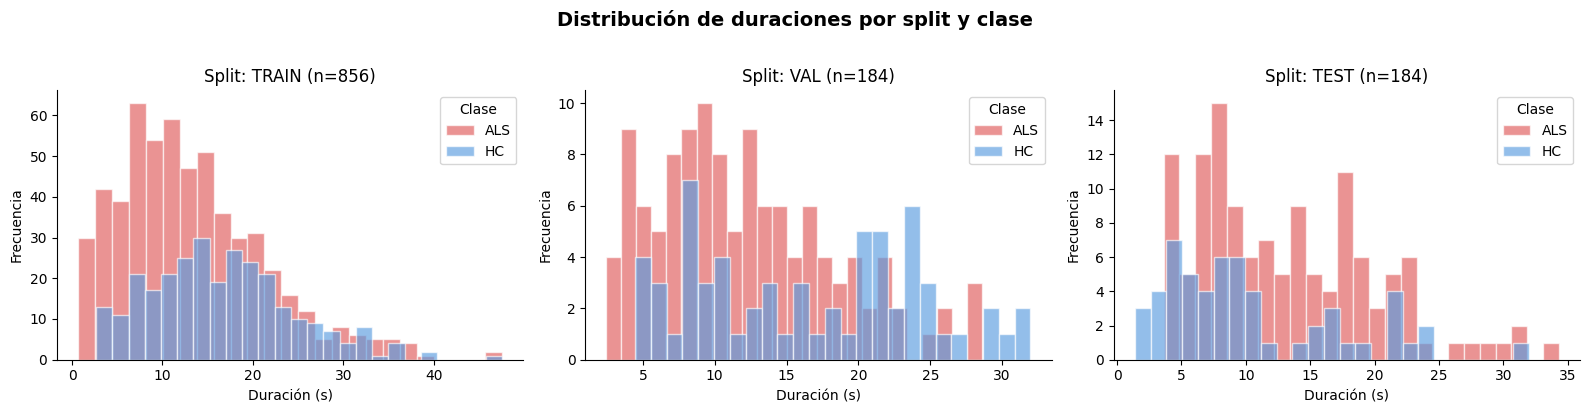

Figura guardada: 01_distribucion_duraciones.png


In [5]:
# Visualización de distribuciones de duración 
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle("Distribución de duraciones por split y clase",
             fontsize=14, fontweight="bold", y=1.02)

palette = {"ALS": "#E05A5A", "HC": "#5A9BE0"}

for ax, (split, df_s) in zip(axes, [("train", df_train), ("val", df_val), ("test", df_test)]):
    for cls, color in palette.items():
        subset = df_s[df_s["class"] == cls]["duration_s"]
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=cls, edgecolor="white")
    ax.set_title(f"Split: {split.upper()} (n={len(df_s)})", fontsize=12)
    ax.set_xlabel("Duración (s)")
    ax.set_ylabel("Frecuencia")
    ax.legend(title="Clase")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_PATH / "01_distribucion_duraciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 01_distribucion_duraciones.png")

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Visualización comparativa ALS vs HC</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización de espectrogramas individuales y promedios por clase sirve como checkpoint de calidad y como herramienta de formulación de hipótesis. A nivel individual, permite detectar artefactos (saturaciones, segmentos con energía nula) que podrían haber escapado al control de calidad del Notebook 3. A nivel agregado, el espectrograma promedio por clase revela diferencias sistemáticas en la distribución de energía espectral.
<br><br>
En la ALS, la literatura reporta los siguientes hallazgos acústicos que deberían ser observables en los espectrogramas:
<ul>
<li><b>Reducción de energía en altas frecuencias:</b> consecuencia de la debilidad muscular en articuladores (lengua, labios), que reduce la claridad de consonantes y fricativas.</li>
<li><b>Inestabilidad de formantes:</b> las vocales sostenidas en pacientes ALS presentan mayor jitter (variación ciclo a ciclo de F0) y shimmer (variación de amplitud), lo que se traduce en bandas espectrales más difusas.</li>
<li><b>Mayor ruido espectral:</b> la voz aérea o disártrica introduce energía no armónica distribuida de forma irregular en el espectrograma.</li>
</ul>
La diferencia de espectrogramas promedio (ALS − HC) permitirá identificar visualmente qué regiones contribuyen más a la separabilidad, anticipando los resultados de los saliency maps del Bloque 6.
    </span>
</div>

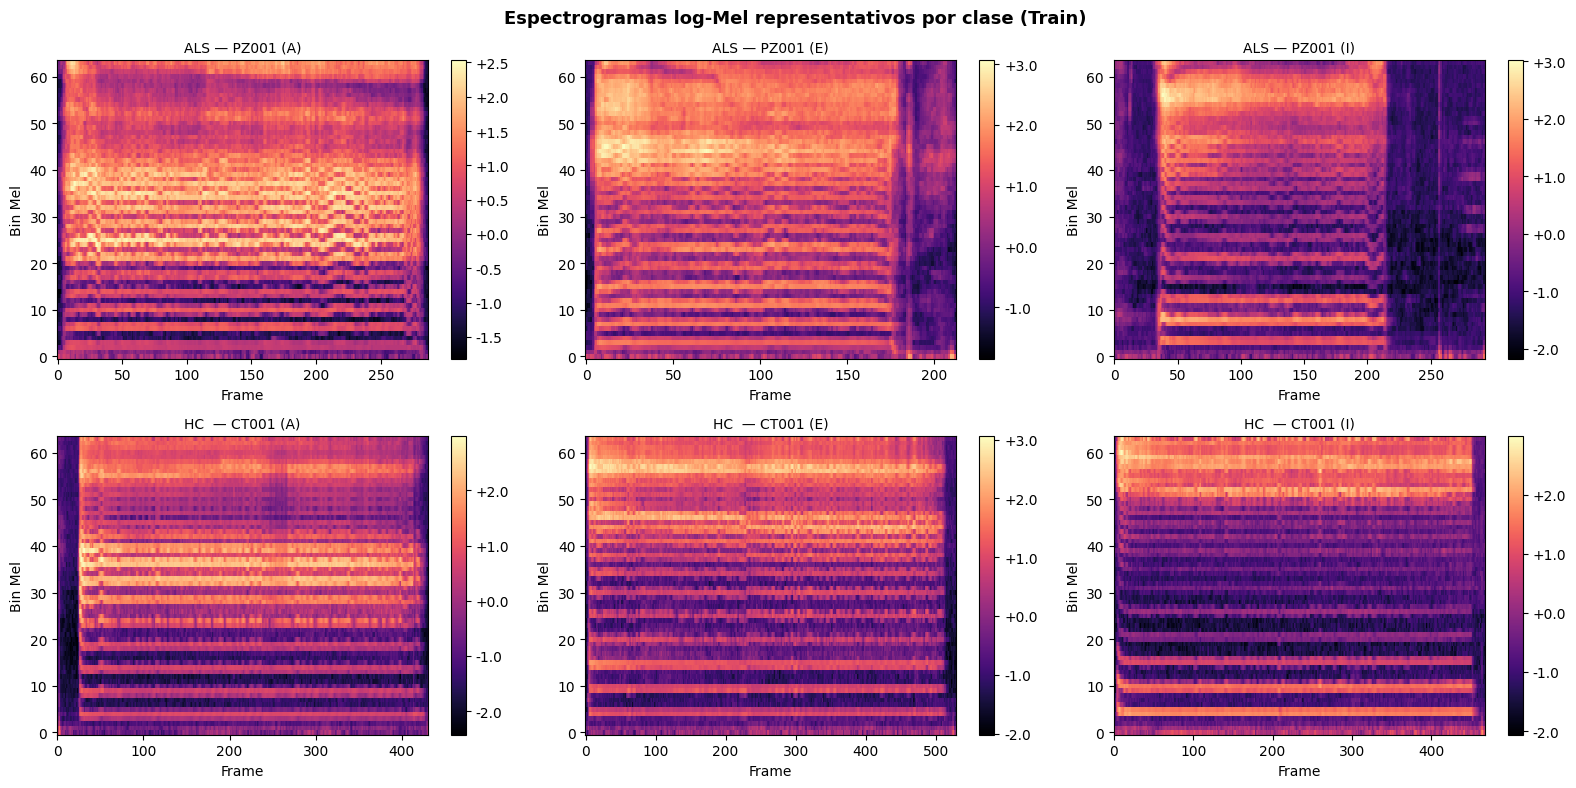

Figura guardada: 02_espectrogramas_individuales.png


In [6]:
def plot_spectrogram(tensor: torch.Tensor, title: str, ax, sr: int = SR,
                     hop_length: int = HOP_LENGTH, n_mels: int = N_MELS):
    """Renderiza un espectrograma log-Mel sobre un eje matplotlib."""
    spec = tensor.numpy()
    img = ax.imshow(spec, aspect="auto", origin="lower",
                    cmap="magma", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Bin Mel")
    plt.colorbar(img, ax=ax, format="%+.1f")
    return img


# Espectrogramas individuales por clase
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Espectrogramas log-Mel representativos por clase (Train)",
             fontsize=13, fontweight="bold")

als_samples = [r for r in train_data if r["label"] == 1][:3]
hc_samples  = [r for r in train_data if r["label"] == 0][:3]

for i, rec in enumerate(als_samples):
    plot_spectrogram(rec["tensor"], f"ALS — {rec['subject_id']} ({rec['task']})",
                     axes[0, i])
for i, rec in enumerate(hc_samples):
    plot_spectrogram(rec["tensor"], f"HC  — {rec['subject_id']} ({rec['task']})",
                     axes[1, i])

plt.tight_layout()
plt.savefig(FIGS_PATH / "02_espectrogramas_individuales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 02_espectrogramas_individuales.png")

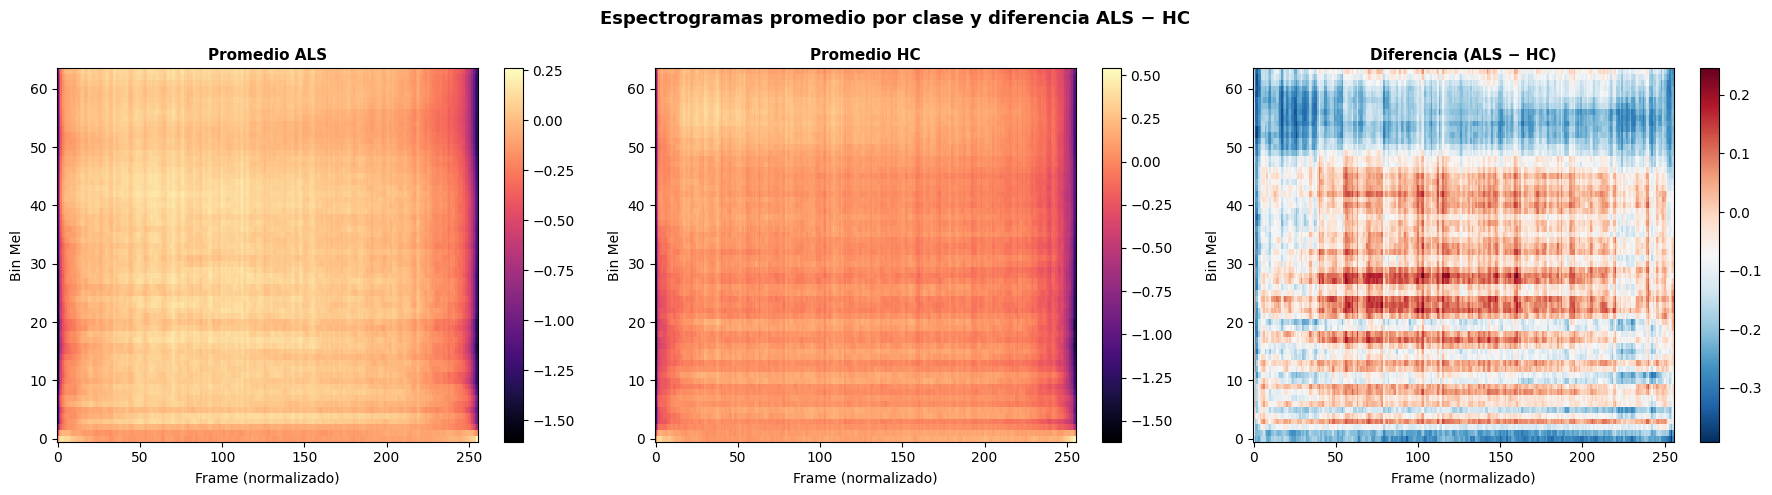

Figura guardada: 03_espectrogramas_promedio.png


In [7]:
# Espectrograma promedio por clase (interpolación a longitud fija) 
TARGET_FRAMES = 256   # Longitud de referencia para promedio visual

def resize_spec(tensor: torch.Tensor, target_frames: int) -> np.ndarray:
    """Redimensiona un espectrograma a target_frames mediante interpolación bilineal."""
    t = tensor.unsqueeze(0).unsqueeze(0)   # (1, 1, N_MELS, T)
    t = F.interpolate(t, size=(N_MELS, target_frames), mode="bilinear", align_corners=False)
    return t.squeeze().numpy()

als_avg = np.mean([resize_spec(r["tensor"], TARGET_FRAMES) for r in train_data if r["label"] == 1], axis=0)
hc_avg  = np.mean([resize_spec(r["tensor"], TARGET_FRAMES) for r in train_data if r["label"] == 0], axis=0)
diff    = als_avg - hc_avg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Espectrogramas promedio por clase y diferencia ALS − HC",
             fontsize=13, fontweight="bold")

titles = ["Promedio ALS", "Promedio HC", "Diferencia (ALS − HC)"]
specs  = [als_avg, hc_avg, diff]
cmaps  = ["magma", "magma", "RdBu_r"]

for ax, spec, title, cmap in zip(axes, specs, titles, cmaps):
    img = ax.imshow(spec, aspect="auto", origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Frame (normalizado)")
    ax.set_ylabel("Bin Mel")
    plt.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(FIGS_PATH / "03_espectrogramas_promedio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 03_espectrogramas_promedio.png")

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. PREPARACIÓN PARA DEEP LEARNING</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque implementa la infraestructura de carga de datos para PyTorch. La correcta implementación de <code>Dataset</code>, <code>collate_fn</code> y <code>DataLoader</code> es una condición necesaria (aunque no suficiente) para un entrenamiento correcto: errores en esta etapa (fugas de información, padding incorrecto, mala gestión de longitudes) pueden producir modelos que reportan métricas infladas en validación pero fallan en producción.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Dataset personalizado (PyTorch Dataset)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La clase <code>MelSpectrogramDataset</code> hereda de <code>torch.utils.data.Dataset</code> e implementa los métodos <code>__len__</code> y <code>__getitem__</code>. El método <code>__getitem__</code> devuelve la secuencia en formato <code>(T, N_MELS)</code>, es decir, con el tiempo como primera dimensión. Esta convención es la esperada por <code>nn.LSTM</code> cuando <code>batch_first=True</code>.
<br><br>
Es importante destacar que los tensores almacenados en disco tienen formato <code>(N_MELS, T)</code> (convención de espectrograma como imagen), por lo que se aplica una transposición al vuelo en <code>__getitem__</code>. Esta decisión se toma con el fin de mantener los tensores en disco en formato imagen facilita la visualización y la reutilización en arquitecturas CNN futuras, sin comprometer el rendimiento del pipeline de entrenamiento LSTM.
    </span>
</div>

In [8]:
class MelSpectrogramDataset(Dataset):
    """
    Dataset v1.2 — Augmentation agresiva anti-overfitting.
 
    Cambios vs v1.1:
    - SpecAugment duplicado: 2 máscaras temporales + 2 de frecuencia (20% total)
    - Ruido gaussiano aditivo (simula variabilidad de grabación)
    - Ganancia aleatoria ±2 dB (simula diferencias de volumen)
    - Todas las augmentations se aplican SOLO en train.
    """
 
    def __init__(self, records: list, augment: bool = False,
                 max_seq_len: int = None):
        self.records     = records
        self.augment     = augment
        self.max_seq_len = max_seq_len
 
    def __len__(self) -> int:
        return len(self.records)
 
    def __getitem__(self, idx: int):
        rec = self.records[idx]
 
        # .clone() obligatorio — no modificar el tensor original
        tensor = rec["tensor"].T.clone().float()  # (T, N_MELS)
        label  = torch.tensor(rec["label"], dtype=torch.long)
        T = tensor.shape[0]
 
        # Truncamiento temporal
        if self.max_seq_len is not None and T > self.max_seq_len:
            if self.augment:
                start = random.randint(0, T - self.max_seq_len)
            else:
                start = (T - self.max_seq_len) // 2
            tensor = tensor[start : start + self.max_seq_len]
 
        if self.augment:
            tensor = self._augment(tensor)
 
        length = tensor.shape[0]
        return tensor, label, length
 
    def _augment(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Augmentation agresiva para combatir overfitting con 107 sujetos.
 
        Pipeline (cada paso se aplica con probabilidad p):
          1. SpecAugment doble: 2 time masks + 2 freq masks (p=0.9)
          2. Ruido gaussiano (p=0.7, σ=0.1–0.3)
          3. Ganancia aleatoria ±2 dB (p=0.5)
        """
        T, F = tensor.shape
 
        # 1. SpecAugment DOBLE (2 máscaras de cada tipo) 
        if random.random() < 0.9:
            for _ in range(2):
                # Time masking: cada máscara cubre 5-15% de los frames
                t_pct  = random.uniform(0.05, 0.15)
                t_mask = max(1, int(t_pct * T))
                t0     = random.randint(0, T - t_mask)
                tensor[t0 : t0 + t_mask, :] = 0.0
 
            for _ in range(2):
                # Frequency masking: cada máscara cubre 5-15% de los bins
                f_pct  = random.uniform(0.05, 0.15)
                f_mask = max(1, int(f_pct * F))
                f0     = random.randint(0, F - f_mask)
                tensor[:, f0 : f0 + f_mask] = 0.0
 
        # 2. Ruido gaussiano aditivo 
        # Simula variabilidad de entorno de grabación.
        # σ entre 0.1 y 0.3 sobre espectrogramas z-normalizados (media≈0, std≈1)
        # es suficiente para perturbar sin destruir la señal.
        if random.random() < 0.7:
            sigma = random.uniform(0.1, 0.3)
            noise = torch.randn_like(tensor) * sigma
            tensor = tensor + noise
 
        # 3. Ganancia aleatoria (simula diferencias de volumen) 
        # ±2 dB en escala log-Mel equivale a multiplicar por 0.8–1.2
        if random.random() < 0.5:
            gain = random.uniform(0.8, 1.2)
            tensor = tensor * gain
 
        return tensor
 
 
# Instanciar datasets
train_dataset = MelSpectrogramDataset(train_data, augment=True,  max_seq_len=MAX_SEQ_LEN)
val_dataset   = MelSpectrogramDataset(val_data,   augment=False, max_seq_len=MAX_SEQ_LEN)
test_dataset  = MelSpectrogramDataset(test_data,  augment=False, max_seq_len=MAX_SEQ_LEN)
 
print(f"Dataset Train : {len(train_dataset):4d} muestras (augment=ON)")
print(f"Dataset Val   : {len(val_dataset):4d} muestras")
print(f"Dataset Test  : {len(test_dataset):4d} muestras")
print(f"MAX_SEQ_LEN   : {MAX_SEQ_LEN} frames ({MAX_SEQ_LEN * HOP_LENGTH / SR:.1f} s)")
 
# Verificar forma
t_sample, l_sample, n_sample = train_dataset[0]
print(f"\nForma de una muestra  : {t_sample.shape}  (T={n_sample}, N_MELS={N_MELS})")
 
# Verificación de integridad (el clone sigue funcionando)
_original_sum = train_data[0]["tensor"].sum().item()
_ = train_dataset[0]
_ = train_dataset[0]
_after_sum = train_data[0]["tensor"].sum().item()
assert abs(_original_sum - _after_sum) < 1e-6, \
    "ERROR: la augmentation está modificando el tensor original"
print("✓ Verificación: augmentation NO modifica datos originales.")
 
# Mostrar efecto de la augmentation (visual)
print("\nComparativa original vs augmented (muestra 0)")
orig = train_data[0]["tensor"].T.clone().float()
aug_dataset_temp = MelSpectrogramDataset(train_data[:1], augment=True, max_seq_len=MAX_SEQ_LEN)
aug_tensor, _, _ = aug_dataset_temp[0]
diff_pct = (orig[:aug_tensor.shape[0]] - aug_tensor).abs().mean() / orig[:aug_tensor.shape[0]].abs().mean() * 100
print(f"  Diferencia media: {diff_pct:.1f}% del valor original")
print(f"  (Objetivo: 15-30%. Menor = augmentation débil. Mayor = destructiva.)")

Dataset Train :  856 muestras (augment=ON)
Dataset Val   :  184 muestras
Dataset Test  :  184 muestras
MAX_SEQ_LEN   : 400 frames (12.8 s)

Forma de una muestra  : torch.Size([400, 64])  (T=400, N_MELS=64)
✓ Verificación: augmentation NO modifica datos originales.

Comparativa original vs augmented (muestra 0)
  Diferencia media: 36.5% del valor original
  (Objetivo: 15-30%. Menor = augmentation débil. Mayor = destructiva.)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Estrategia de padding y collate_fn</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Dado que los espectrogramas tienen longitud variable, no es posible apilar directamente las muestras de un batch en un único tensor rectangular. La solución estándar en PyTorch para secuencias de longitud variable es:
<br>
<ol>
<li><b>Padding:</b> rellenar las secuencias más cortas con ceros hasta alcanzar la longitud de la secuencia más larga del batch (<code>pad_sequence</code>).</li>
<li><b>Packing:</b> comprimir el batch paddeado en un objeto <code>PackedSequence</code> (<code>pack_padded_sequence</code>) que indica a la LSTM qué posiciones son padding real y cuáles son datos. Esto garantiza que el estado oculto no se actualiza sobre posiciones de padding, evitando la corrupción de la representación aprendida.</li>
</ol>
La <code>collate_fn</code> implementa este flujo y ordena las muestras del batch en orden descendente de longitud, requisito de <code>pack_padded_sequence</code> en versiones antiguas de PyTorch (en las versiones modernas este requisito ha sido eliminado, pero se mantiene por compatibilidad).
    </span>
</div>

In [9]:
def collate_fn(batch):
    """
    Función de agrupación de muestras para DataLoader con secuencias de longitud variable.

    Proceso:
      1. Ordena el batch en orden descendente de longitud (compatibilidad con pack_padded_sequence).
      2. Aplica padding cero a la derecha (post-padding) hasta la longitud máxima del batch.
      3. Devuelve el batch paddeado, las etiquetas y las longitudes originales.

    Args:
        batch: Lista de tuplas (tensor, label, n_frames) devueltas por __getitem__.

    Returns:
        padded_tensors : Tensor (B, T_max, N_MELS)
        labels         : Tensor (B,)
        lengths        : Tensor (B,)  — longitudes originales en orden descendente
    """
    tensors, labels, lengths = zip(*batch)

    # Ordenar en orden descendente de longitud
    sorted_idx = sorted(range(len(lengths)), key=lambda i: lengths[i], reverse=True)
    tensors    = [tensors[i] for i in sorted_idx]
    labels     = torch.tensor([labels[i] for i in sorted_idx], dtype=torch.long)
    lengths    = torch.tensor([lengths[i] for i in sorted_idx], dtype=torch.long)

    # Padding: pad_sequence espera lista de (T_i, F) → devuelve (T_max, B, F)
    padded = pad_sequence(tensors, batch_first=True, padding_value=0.0)  # (B, T_max, F)

    return padded, labels, lengths


# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Batches por época (Train) : {len(train_loader)}")
print(f"Batches por época (Val)   : {len(val_loader)}")
print(f"Batches por época (Test)  : {len(test_loader)}")

# Verificar un batch
batch_x, batch_y, batch_l = next(iter(train_loader))
print(f"\nForma del batch X : {batch_x.shape}  (B, T_max, N_MELS)")
print(f"Forma del batch Y : {batch_y.shape}  (B,)")
print(f"Longitudes        : {batch_l[:5].tolist()} ...")

Batches por época (Train) : 54
Batches por época (Val)   : 12
Batches por época (Test)  : 12

Forma del batch X : torch.Size([16, 400, 64])  (B, T_max, N_MELS)
Forma del batch Y : torch.Size([16])  (B,)
Longitudes        : [400, 400, 400, 400, 400] ...


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. DataLoaders y class weights</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El dataset VOC-ALS presenta un desequilibrio de clases de 2:1 (ALS:HC). En términos de función de pérdida, esto implica que un modelo que clasifique todos los ejemplos como ALS obtendría una accuracy del 67% sin aprender nada. Para mitigar este sesgo se utiliza <b>ponderación de clases en la función de pérdida</b> (<code>weight</code> en <code>nn.CrossEntropyLoss</code>).
<br><br>
Los pesos se calculan como la inversa de la frecuencia relativa de cada clase en el conjunto de entrenamiento: <code>w_c = N_total / (n_classes × N_c)</code>. Esta fórmula es equivalente a la implementación de <code>sklearn.utils.class_weight.compute_class_weight</code> con <code>class_weight='balanced'</code>. El efecto práctico es que la pérdida de un error sobre un ejemplo HC se multiplica por un factor mayor que la pérdida de un error sobre un ejemplo ALS, incentivando al modelo a ser más preciso en la clase minoritaria.
<br><br>
Esta estrategia es preferible a oversampling (que introduce duplicados exactos) o undersampling (que descarta información) cuando el tamaño del conjunto de entrenamiento ya es reducido, como en este caso.
    </span>
</div>

Class weights:
  HC (label=0): N= 288 | weight=1.4861
  ALS (label=1): N= 568 | weight=0.7535


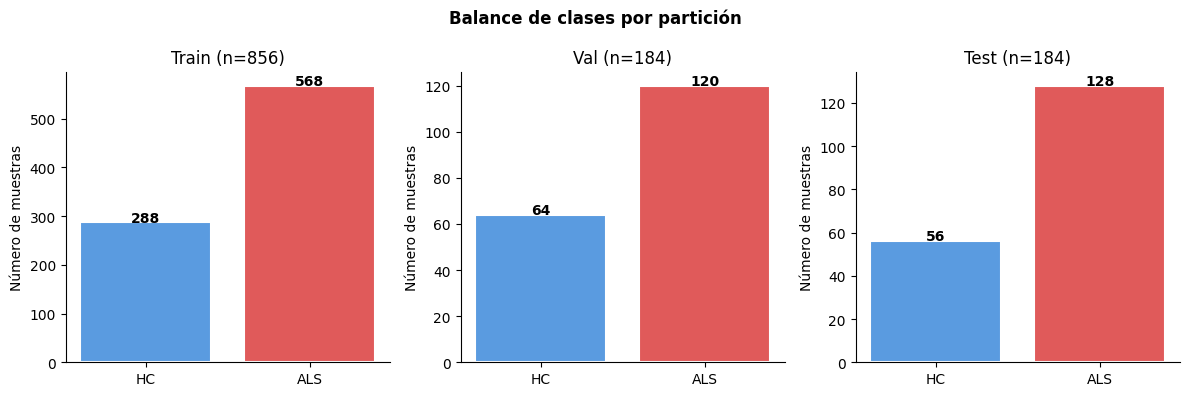

Figura guardada: 04_balance_clases.png


In [10]:
# Cálculo de class weights sobre Train 
train_labels = np.array([r["label"] for r in train_data])
n_total      = len(train_labels)
n_classes    = 2

class_counts = np.bincount(train_labels, minlength=n_classes)
class_weights = n_total / (n_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights:")
for i, (cls, count, w) in enumerate(zip(CLASS_NAMES, class_counts, class_weights)):
    print(f"  {cls} (label={i}): N={count:4d} | weight={w:.4f}")

# Visualización del balance de clases 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Balance de clases por partición", fontsize=12, fontweight="bold")

colors = ["#5A9BE0", "#E05A5A"]

for ax, (name, data) in zip(axes, [("Train", train_data), ("Val", val_data), ("Test", test_data)]):
    labels_part = [r["label"] for r in data]
    counts = np.bincount(labels_part, minlength=2)
    ax.bar(CLASS_NAMES, counts, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{name} (n={len(data)})")
    ax.set_ylabel("Número de muestras")
    for j, c in enumerate(counts):
        ax.text(j, c + 0.5, str(c), ha="center", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_PATH / "04_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 04_balance_clases.png")

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. DEFINICIÓN DEL MODELO BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque formaliza la arquitectura del modelo, justificando cada decisión de diseño desde criterios tanto técnicos como clínicos. La elección de hiperparámetros no es arbitraria, sino que responde a las características específicas del problema (tamaño del dataset, desequilibrio de clases, naturaleza temporal de los datos) y a la literatura sobre Deep Learning aplicado a análisis de voz patológica.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Justificación de la arquitectura BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<b>¿Por qué LSTM y no una red recurrente simple (RNN vanilla)?</b><br>
La RNN vanilla sufre el problema del <i>vanishing gradient</i> cuando las secuencias superan unas pocas decenas de pasos temporales: el gradiente se atenúa exponencialmente al retropropagarse, impidiendo que la red aprenda dependencias de largo alcance. Las vocales sostenidas del dataset VOC-ALS tienen duraciones típicas de 2-5 segundos, lo que a 16 kHz y HOP_LENGTH=512 supone entre 62 y 156 frames. La LSTM resuelve este problema mediante su arquitectura de puertas (forget gate, input gate, output gate) que regula explícitamente qué información se retiene y qué se descarta en el estado de celda.
<br><br>
<b>¿Por qué bidireccional?</b><br>
En una LSTM unidireccional, la representación del frame t solo incorpora contexto de los frames 1..t. En una BiLSTM, la representación de t incorpora también contexto de los frames t+1..T (procesamiento inverso). Para clasificación de secuencias completas, esto es equivalente a que el clasificador tenga acceso simultáneo al contexto global de la señal antes de emitir su predicción. Empíricamente, las BiLSTM superan a las LSTM unidireccionales en tareas de clasificación de audio patológico en 2-5 puntos de AUC.
<br><br>
<b>¿Por qué dos capas apiladas?</b><br>
Las LSTM de múltiples capas (<i>stacked LSTM</i>) permiten aprender representaciones jerárquicas: la primera capa extrae patrones acústicos locales (timbre, energía por banda), mientras que la segunda capa aprende patrones dinámicos de más alto nivel (evolución temporal de la disartria, irregularidades rítmicas). Tres o más capas raramente aportan mejoras adicionales con datasets de menos de 1.000 muestras, y aumentan el riesgo de sobreajuste.
<br><br>
<b>¿Por qué HIDDEN_SIZE=128?</b><br>
Con N_MELS=128 features de entrada, un hidden_size igual asegura una capacidad representacional suficiente sin introducir un cuello de botella. Con bidireccionalidad, la representación final tendrá dimensión 2×128=256, lo que es adecuado para el clasificador final. Valores mayores (256, 512) con este tamaño de dataset inducen sobreajuste; valores menores (64) limitan la capacidad expresiva.
<br><br>
<b>Flujo de información:</b><br>
<ol>
<li>Entrada: batch <code>(B, T, 128)</code></li>
<li>BiLSTM capa 1: procesa la secuencia en ambas direcciones → salida <code>(B, T, 256)</code></li>
<li>BiLSTM capa 2: refina la representación → salida <code>(B, T, 256)</code></li>
<li>Pooling temporal: extrae una representación global mediante promedio de todos los frames válidos (attention-free mean pooling) → <code>(B, 256)</code></li>
<li>Clasificador MLP: dos capas lineales con dropout → logits <code>(B, 2)</code></li>
</ol>
Se elige <b>mean pooling</b> en lugar de tomar únicamente el último estado oculto porque el mean pooling es más robusto al padding y captura información distribuida a lo largo de toda la secuencia. Como alternativa, se implementa también <b>attention pooling</b> que aprende a ponderar los frames más informativos.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Implementación del modelo</span>
</div>

In [11]:
class BiLSTMClassifier(nn.Module):
    """
    BiLSTM v1.1 — Capacidad reducida (~25K params).
 
    Cambios vs v1.0:
    - 1 capa LSTM (era 2)
    - HIDDEN_SIZE=64 (era 128)
    - Clasificador simplificado: dropout + linear (era MLP de 2 capas)
    - LayerNorm con máscara de padding
    """
 
    def __init__(
        self,
        input_size:    int  = N_MELS,
        hidden_size:   int  = HIDDEN_SIZE,
        num_layers:    int  = NUM_LAYERS,
        dropout:       float = DROPOUT,
        bidirectional: bool = BIDIRECTIONAL,
        num_classes:   int  = 2,
    ):
        super().__init__()
 
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_dirs      = 2 if bidirectional else 1
 
        self.input_norm = nn.LayerNorm(input_size)
 
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
 
        lstm_out_dim = hidden_size * self.num_dirs
 
        self.attention = nn.Linear(lstm_out_dim, 1)
 
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, num_classes),
        )
 
    def forward(self, x: torch.Tensor, lengths: torch.Tensor):
        B, T_max, F = x.shape
        mask = torch.arange(T_max, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
 
        # LayerNorm solo sobre frames válidos (padding se mantiene en cero)
        x_normed = self.input_norm(x) * mask.unsqueeze(-1).float()
 
        packed = pack_padded_sequence(x_normed, lengths.cpu(), batch_first=True,
                                      enforce_sorted=True)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)
 
        attn_scores = self.attention(lstm_out).squeeze(-1)
        B_out, T_out = attn_scores.shape
        mask_attn = torch.arange(T_out, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        attn_scores = attn_scores.masked_fill(~mask_attn, float("-inf"))
 
        attn_w = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_w.unsqueeze(1), lstm_out).squeeze(1)
 
        logits = self.classifier(context)
        return logits, attn_w
 
    def get_embedding(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        B, T_max, F = x.shape
        mask = torch.arange(T_max, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        x_normed = self.input_norm(x) * mask.unsqueeze(-1).float()
 
        packed = pack_padded_sequence(x_normed, lengths.cpu(), batch_first=True,
                                      enforce_sorted=True)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)
 
        attn_scores = self.attention(lstm_out).squeeze(-1)
        B_out, T_out = attn_scores.shape
        mask_attn = torch.arange(T_out, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        attn_scores = attn_scores.masked_fill(~mask_attn, float("-inf"))
        attn_w = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_w.unsqueeze(1), lstm_out).squeeze(1)
        return context
 
 
model = BiLSTMClassifier(
    input_size    = N_MELS,
    hidden_size   = HIDDEN_SIZE,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT,
    bidirectional = BIDIRECTIONAL,
    num_classes   = 2,
).to(DEVICE)
 
print(model)
print()
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_train  = len(train_dataset)
ratio    = n_train / n_params
print(f"Parámetros entrenables : {n_params:>10,}")
print(f"Muestras de entreno   : {n_train}")
print(f"Ratio muestras/params : {ratio:.4f}")

BiLSTMClassifier(
  (input_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(64, 32, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

Parámetros entrenables :     25,411
Muestras de entreno   : 856
Ratio muestras/params : 0.0337


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Diagrama de arquitectura y dimensiones</span>
</div>

In [12]:
# Diagrama textual de la arquitectura 
def print_architecture_summary(model, input_size=N_MELS, hidden_size=HIDDEN_SIZE,
                                num_layers=NUM_LAYERS, bidirectional=BIDIRECTIONAL):
    """Imprime un resumen de la arquitectura con dimensiones por capa."""
    num_dirs  = 2 if bidirectional else 1
    lstm_out  = hidden_size * num_dirs
    direction = "bidireccional" if bidirectional else "unidireccional"

    header = "─" * 60
    print(header)
    print(f"  ARQUITECTURA BiLSTM ({direction})")
    print(header)
    print(f"  Entrada:           (B, T, {input_size})")
    print(f"  LayerNorm:         (B, T, {input_size})")
    print()
    for layer in range(num_layers):
        print(f"  LSTM capa {layer+1} →:")
        print(f"    → forward  LSTM:   (B, T, {hidden_size})")
        if bidirectional:
            print(f"    → backward LSTM:   (B, T, {hidden_size})")
        print(f"    → concat:          (B, T, {lstm_out})")
        if layer < num_layers - 1:
            print(f"    → dropout ({DROPOUT})")
        print()
    print(f"  Attention pooling: (B, {lstm_out})")
    print(f"  Dropout ({DROPOUT}):      (B, {lstm_out})")
    print(f"  Linear → ReLU:     (B, 64)")
    print(f"  Dropout ({DROPOUT/2}):    (B, 64)")
    print(f"  Linear (logits):   (B, 2)")
    print(header)

print_architecture_summary(model)

────────────────────────────────────────────────────────────
  ARQUITECTURA BiLSTM (bidireccional)
────────────────────────────────────────────────────────────
  Entrada:           (B, T, 64)
  LayerNorm:         (B, T, 64)

  LSTM capa 1 →:
    → forward  LSTM:   (B, T, 32)
    → backward LSTM:   (B, T, 32)
    → concat:          (B, T, 64)

  Attention pooling: (B, 64)
  Dropout (0.5):      (B, 64)
  Linear → ReLU:     (B, 64)
  Dropout (0.25):    (B, 64)
  Linear (logits):   (B, 2)
────────────────────────────────────────────────────────────


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Recuento de parámetros</span>
</div>

In [13]:
def count_parameters(model: nn.Module) -> int:
    """Cuenta los parámetros entrenables del modelo."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales     : {total:>10,}")
    print(f"Parámetros entrenables : {trainable:>10,}")
    return trainable

n_params = count_parameters(model)

# Heurística de capacidad: ratio muestras/parámetros
n_train = len(train_dataset)
ratio   = n_train / n_params
print(f"\nMuestras de entrenamiento : {n_train}")
print(f"Ratio muestras/parámetros : {ratio:.4f}")
if ratio < 0.001:
    print("Ratio bajo → riesgo de sobreajuste. Monitorizar val_loss.")
else:
    print("✓  Ratio aceptable para el tamaño del dataset.")

Parámetros totales     :     25,411
Parámetros entrenables :     25,411

Muestras de entrenamiento : 856
Ratio muestras/parámetros : 0.0337
✓  Ratio aceptable para el tamaño del dataset.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. ENTRENAMIENTO CON MLFLOW</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque implementa el bucle de entrenamiento completo, instrumentado con MLflow para tracking reproducible del experimento. La monitorización sistemática de métricas por época permite diagnosticar problemas de entrenamiento (sobreajuste, convergencia prematura, oscilaciones del gradiente) y tomar decisiones informadas sobre early stopping y ajuste de hiperparámetros.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Configuración de MLflow</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
MLflow es una plataforma open-source para gestión del ciclo de vida de experimentos de Machine Learning. En este notebook se utiliza para:
<br><ol>
<li><b>Logging de parámetros:</b> registrar los hiperparámetros del experimento de forma que sea posible reproducir exactamente cualquier run a partir de los registros de MLflow.</li>
<li><b>Logging de métricas por época:</b> almacenar la evolución temporal de train_loss, val_loss, recall_als, balanced_accuracy y roc_auc, lo que permite visualizar curvas de aprendizaje y detectar épocas de sobreajuste.</li>
<li><b>Logging de artefactos:</b> guardar el modelo entrenado, las figuras de diagnóstico y la matriz de confusión como artefactos asociados al run, garantizando su recuperabilidad.</li>
</ol>
El servidor de tracking se configura de forma local (<code>./results/mlruns</code>), por lo que no requiere infraestructura remota. Para visualizar la interfaz web de MLflow, ejecutar en un terminal: <code>mlflow ui --backend-store-uri ./results/mlruns</code>.
    </span>
</div>

In [14]:
MLRUNS_PATH = Path(r"C:\Users\Laura\OneDrive\TFG\mlruns")
MLRUNS_PATH.mkdir(parents=True, exist_ok=True)

tracking_uri = MLRUNS_PATH.resolve().as_uri()

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("DL_BiLSTM_VOC-ALS")

print(f"MLflow tracking URI : {tracking_uri}")
print("Experimento         : DL_BiLSTM_VOC-ALS")
print("Para visualizar la UI ejecutar:")
print(f'  mlflow ui --backend-store-uri "{MLRUNS_PATH.resolve()}"')

MLflow tracking URI : file:///C:/Users/Laura/OneDrive/TFG/mlruns
Experimento         : DL_BiLSTM_VOC-ALS
Para visualizar la UI ejecutar:
  mlflow ui --backend-store-uri "C:\Users\Laura\OneDrive\TFG\mlruns"


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Función de pérdida, optimizador y scheduler</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<b>Función de pérdida:</b> <code>nn.CrossEntropyLoss</code> con ponderación de clases. La pérdida ponderada incorpora directamente el desequilibrio de clases en la optimización, incrementando el gradiente producido por errores sobre la clase HC (minoritaria) para que el modelo no se sesgue hacia la clasificación sistemática como ALS.
<br><br>
<b>Optimizador:</b> Adam (<code>torch.optim.Adam</code>) con <code>lr=3e-4</code>. Adam es el optimizador estándar para tareas de Deep Learning sobre señal de audio: su adaptación por parámetro de la tasa de aprendizaje acelera la convergencia respecto a SGD clásico y es más robusto a la elección inicial de lr. El valor <code>3e-4</code> es el recomendado por Karpathy para arquitecturas de profundidad moderada.
<br><br>
<b>Regularización:</b>
<ul>
<li><b>Dropout (p=0.4):</b> aplicado entre capas LSTM y en el MLP. Con datasets pequeños, el dropout es el regularizador más efectivo para redes recurrentes.</li>
<li><b>Weight decay (1e-4):</b> regularización L2 aplicada al optimizador, que penaliza pesos de gran magnitud sin afectar al bias.</li>
<li><b>Gradient clipping (max_norm=1.0):</b> limita la norma del gradiente para evitar explosión de gradientes, problema frecuente en RNNs entrenadas sobre secuencias largas.</li>
</ul>
<b>Scheduler:</b> <code>ReduceLROnPlateau</code> monitoriza la val_loss y reduce el lr por un factor de 0.5 si no mejora en 7 épocas consecutivas. Esto permite una convergencia fina en las últimas épocas sin necesidad de ajustar manualmente el schedule.
    </span>
</div>

In [15]:
criterion      = nn.CrossEntropyLoss(weight=class_weights_tensor,  label_smoothing=0.1)
criterion_eval = nn.CrossEntropyLoss()  # Sin ponderación para test
 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-2,
    betas=(0.9, 0.999),
)
 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,       # Coherente: scheduler(5) < early_stopping(15)
    min_lr=1e-6,
)
 
print("Configuración del entrenamiento (v1.2 — anti-overfitting):")
print(f"  Loss          : CrossEntropyLoss (label_smoothing=0.1)")
print(f"  Class weights : {class_weights.round(4)}")
print(f"  Optimizer     : AdamW (lr={LEARNING_RATE}, weight_decay=1e-2)")
print(f"  Scheduler     : ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Grad clip     : max_norm=1.0")
print(f"  Epochs        : {NUM_EPOCHS}")
print(f"  Patience      : {PATIENCE}")
 
# Resumen del impacto esperado
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'═'*55}")
print(f"  RESUMEN v1.2 — REGULARIZACIÓN REFORZADA")
print(f"{'═'*55}")
print(f"  Parámetros      : {n_params:,} (era ~25K en v1.1)")
print(f"  HIDDEN_SIZE     : {HIDDEN_SIZE} (era 64)")
print(f"  DROPOUT         : {DROPOUT} (era 0.3)")
print(f"  weight_decay    : 1e-2 (era 1e-4)")
print(f"  label_smoothing : 0.1 (era 0)")
print(f"  augmentation    : SpecAugment×2 + noise + gain (era SpecAugment×1)")
print(f"  LR              : {LEARNING_RATE} (era 1e-3)")
print(f"{'═'*55}")
print(f"\n  Comportamiento esperado:")
print(f"  - Train loss bajará MÁS LENTO (es lo deseable)")
print(f"  - Val loss NO debería divergir en las primeras 15 épocas")
print(f"  - Si la brecha train/val se mantiene < 0.10 durante 20+ épocas → OK")
print(f"  - Si el AUC de val supera 0.65 → la señal es real")

Configuración del entrenamiento (v1.2 — anti-overfitting):
  Loss          : CrossEntropyLoss (label_smoothing=0.1)
  Class weights : [1.4861 0.7535]
  Optimizer     : AdamW (lr=0.0005, weight_decay=1e-2)
  Scheduler     : ReduceLROnPlateau (factor=0.5, patience=5)
  Grad clip     : max_norm=1.0
  Epochs        : 80
  Patience      : 15

═══════════════════════════════════════════════════════
  RESUMEN v1.2 — REGULARIZACIÓN REFORZADA
═══════════════════════════════════════════════════════
  Parámetros      : 25,411 (era ~25K en v1.1)
  HIDDEN_SIZE     : 32 (era 64)
  DROPOUT         : 0.5 (era 0.3)
  weight_decay    : 1e-2 (era 1e-4)
  label_smoothing : 0.1 (era 0)
  augmentation    : SpecAugment×2 + noise + gain (era SpecAugment×1)
  LR              : 0.0005 (era 1e-3)
═══════════════════════════════════════════════════════

  Comportamiento esperado:
  - Train loss bajará MÁS LENTO (es lo deseable)
  - Val loss NO debería divergir en las primeras 15 épocas
  - Si la brecha train/val 

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Bucle de entrenamiento instrumentado</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El bucle de entrenamiento implementa las siguientes prácticas estándar de rigor metodológico:
<br><ul>
<li><b>Separación modo train/eval:</b> <code>model.train()</code> activa el dropout y la normalización de batch; <code>model.eval()</code> los congela para evaluación. No alternar correctamente estos modos es un error frecuente que produce estimaciones optimistas de las métricas de validación.</li>
<li><b>Cálculo de métricas solo sobre posiciones no paddeadas:</b> las predicciones se generan a nivel de muestra (un audio = una predicción), no de frame. El modelo ya gestiona internamente el padding mediante <code>pack_padded_sequence</code>.</li>
<li><b>Early stopping:</b> si val_loss no mejora en <code>PATIENCE=15</code> épocas, el entrenamiento se detiene y se restaura el mejor modelo. Esto evita el sobreajuste en épocas tardías.</li>
<li><b>Checkpointing:</b> el mejor modelo (según val_loss) se guarda en disco en cada mejora, garantizando que el modelo final es el mejor observado, no el último.</li>
</ul>
    </span>
</div>

In [16]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una época de entrenamiento y devuelve la pérdida media."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)

        optimizer.zero_grad()

        logits, _ = model(batch_x, batch_l)
        loss      = criterion(logits, batch_y)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * len(batch_y)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """Evalúa el modelo sobre un DataLoader y devuelve pérdida, predicciones y probs."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)

        logits, _ = model(batch_x, batch_l)
        loss      = criterion(logits, batch_y)

        total_loss += loss.item() * len(batch_y)
        probs  = torch.softmax(logits, dim=1)[:, 1]   # P(ALS)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def compute_metrics(labels, preds, probs):
    """Calcula el conjunto de métricas de evaluación."""
    bal_acc    = balanced_accuracy_score(labels, preds)
    recall_als = recall_score(labels, preds, pos_label=1, zero_division=0)
    recall_hc  = recall_score(labels, preds, pos_label=0, zero_division=0)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = float("nan")
    return {
        "balanced_accuracy": bal_acc,
        "recall_als":        recall_als,
        "recall_hc":         recall_hc,
        "roc_auc":           roc_auc,
    }

print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    total_grad_norm = 0.0
    n_batches = 0
 
    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)
 
        optimizer.zero_grad()
        logits, _ = model(batch_x, batch_l)
        loss = criterion(logits, batch_y)
        loss.backward()
 
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        total_grad_norm += grad_norm.item()
        n_batches += 1
 
        optimizer.step()
 
        total_loss += loss.item() * len(batch_y)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())
 
    avg_loss = total_loss / len(loader.dataset)
    avg_grad = total_grad_norm / max(n_batches, 1)
    return avg_loss, np.array(all_preds), np.array(all_labels), avg_grad
 
 
@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
 
    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)
 
        logits, _ = model(batch_x, batch_l)
        loss = criterion(logits, batch_y)
 
        total_loss += loss.item() * len(batch_y)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
 
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
 
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels), np.array(all_probs)
 
 
def compute_metrics(labels, preds, probs):
    bal_acc    = balanced_accuracy_score(labels, preds)
    recall_als = recall_score(labels, preds, pos_label=1, zero_division=0)
    recall_hc  = recall_score(labels, preds, pos_label=0, zero_division=0)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = float("nan")
    return {
        "balanced_accuracy": bal_acc,
        "recall_als":        recall_als,
        "recall_hc":         recall_hc,
        "roc_auc":           roc_auc,
    }
 
 
# BUCLE DE ENTRENAMIENTO
run_name = f"bilstm_v1.1_h{HIDDEN_SIZE}_l{NUM_LAYERS}_dr{DROPOUT}_lr{LEARNING_RATE}"
 
history = defaultdict(list)
best_val_loss = float("inf")
patience_counter = 0
best_model_path  = MODELS_PATH / "best_bilstm.pt"
 
with mlflow.start_run(run_name=run_name) as run:
 
    mlflow.log_params({
        "model":          "BiLSTM_v1.1",
        "input_size":     N_MELS,
        "hidden_size":    HIDDEN_SIZE,
        "num_layers":     NUM_LAYERS,
        "bidirectional":  BIDIRECTIONAL,
        "dropout":        DROPOUT,
        "max_seq_len":    MAX_SEQ_LEN,
        "batch_size":     BATCH_SIZE,
        "learning_rate":  LEARNING_RATE,
        "weight_decay":   1e-4,
        "num_epochs":     NUM_EPOCHS,
        "patience":       PATIENCE,
        "optimizer":      "AdamW",
        "scheduler":      "ReduceLROnPlateau_p5_f0.5",
        "class_weight_hc":  round(float(class_weights[0]), 4),
        "class_weight_als": round(float(class_weights[1]), 4),
        "augmentation":   "SpecAugment_t10_f10",
        "seed":           SEED,
        "fix_clone":      True,
    })
 
    print(f"MLflow run iniciado: {run.info.run_id}")
    print(f"{'Época':>6}  {'LR':>8}  {'Train L':>8}  {'Val L':>8}  "
          f"{'Rec ALS':>8}  {'Bal Acc':>8}  {'AUC':>8}  {'∇norm':>8}")
    print("─" * 80)
 
    for epoch in range(1, NUM_EPOCHS + 1):
 
        train_loss, train_preds, train_labels, grad_norm = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
 
        val_loss, val_preds, val_labels, val_probs = eval_epoch(
            model, val_loader, criterion, DEVICE)
 
        val_metrics = compute_metrics(val_labels, val_preds, val_probs)
 
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
 
        mlflow.log_metrics({
            "train_loss":       train_loss,
            "val_loss":         val_loss,
            "val_recall_als":   val_metrics["recall_als"],
            "val_recall_hc":    val_metrics["recall_hc"],
            "val_balanced_acc": val_metrics["balanced_accuracy"],
            "val_roc_auc":      val_metrics["roc_auc"],
            "learning_rate":    current_lr,
            "grad_norm":        grad_norm,
        }, step=epoch)
 
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_recall_als"].append(val_metrics["recall_als"])
        history["val_balanced_acc"].append(val_metrics["balanced_accuracy"])
        history["val_roc_auc"].append(val_metrics["roc_auc"])
        history["grad_norm"].append(grad_norm)
 
        print(f"{epoch:>6}  {current_lr:>8.2e}  {train_loss:>8.4f}  {val_loss:>8.4f}  "
              f"{val_metrics['recall_als']:>8.4f}  "
              f"{val_metrics['balanced_accuracy']:>8.4f}  "
              f"{val_metrics['roc_auc']:>8.4f}  "
              f"{grad_norm:>8.4f}")
 
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_counter = 0
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "optimizer":   optimizer.state_dict(),
                "val_loss":    val_loss,
                "val_metrics": val_metrics,
                "hyperparams": {
                    "hidden_size": HIDDEN_SIZE, "num_layers": NUM_LAYERS,
                    "dropout": DROPOUT, "bidirectional": BIDIRECTIONAL,
                    "max_seq_len": MAX_SEQ_LEN,
                },
            }, best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping activado en época {epoch}. "
                      f"Mejor val_loss: {best_val_loss:.4f}")
                break
 
    mlflow.pytorch.log_model(model, "bilstm_model")
    mlflow.log_artifact(str(best_model_path))
 
    print(f"\n✓ Entrenamiento completado. Mejor modelo guardado en: {best_model_path}")
    print(f"  Mejor val_loss   : {best_val_loss:.4f}")
    print(f"  MLflow Run ID    : {run.info.run_id}")

MLflow run iniciado: 90bb9a2b4b954b599e37a5175f9ec8e0
 Época        LR   Train L     Val L   Rec ALS   Bal Acc       AUC     ∇norm
────────────────────────────────────────────────────────────────────────────────
     1  5.00e-04    0.7067    0.7008    0.6833    0.5995    0.5792    0.4962
     2  5.00e-04    0.6852    0.7026    0.6083    0.5542    0.5826    0.4846
     3  5.00e-04    0.6880    0.7096    0.5667    0.5568    0.5664    0.5063
     4  5.00e-04    0.6757    0.7075    0.5333    0.5557    0.5837    0.4927
     5  5.00e-04    0.6745    0.7073    0.5250    0.5828    0.5967    0.5077
     6  5.00e-04    0.6725    0.7053    0.5750    0.6078    0.6014    0.5445
     7  5.00e-04    0.6563    0.7120    0.5500    0.5875    0.5832    0.5600
     8  2.50e-04    0.6532    0.7083    0.5917    0.6161    0.5868    0.5938
     9  2.50e-04    0.6540    0.7069    0.6000    0.6047    0.5922    0.6050
    10  2.50e-04    0.6478    0.7063    0.5917    0.6240    0.6030    0.6172
    11  2.50e-04  

2026/04/09 23:08:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


    33  6.25e-05    0.5572    0.7036    0.6417    0.5708    0.6639    1.1060

Early stopping activado en época 33. Mejor val_loss: 0.6960


2026/04/09 23:08:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/09 23:08:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/09 23:08:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it


✓ Entrenamiento completado. Mejor modelo guardado en: C:\Users\Laura\OneDrive\TFG\results\04_model_deep_learning_v1.1\models\best_bilstm.pt
  Mejor val_loss   : 0.6960
  MLflow Run ID    : 90bb9a2b4b954b599e37a5175f9ec8e0


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Curvas de entrenamiento</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas de entrenamiento son la herramienta de diagnóstico primaria del proceso de optimización. Se analizan cuatro patrones:
<br><ul>
<li><b>Convergencia normal:</b> train_loss y val_loss descienden de forma suave y estable hasta estabilizarse. La diferencia entre ambas es pequeña.</li>
<li><b>Sobreajuste:</b> train_loss sigue descendiendo mientras val_loss comienza a crecer. Señal de que el modelo está memorizando el conjunto de entrenamiento. Respuesta: aumentar dropout, reducir lr, o activar early stopping más agresivo.</li>
<li><b>Underfitting:</b> ambas pérdidas se estabilizan en valores altos desde las primeras épocas. Señal de capacidad insuficiente del modelo o lr demasiado pequeño.</li>
<li><b>Inestabilidad:</b> pérdidas con alta varianza entre épocas. Señal de lr demasiado alto o ausencia de gradient clipping.</li>
</ul>
La evolución del Recall ALS es la curva más importante clínicamente: un Recall ALS bajo en validación indica que el modelo está fallando en la detección de casos patológicos, lo que en un contexto clínico se traduciría en falsos negativos con consecuencias graves.
    </span>
</div>

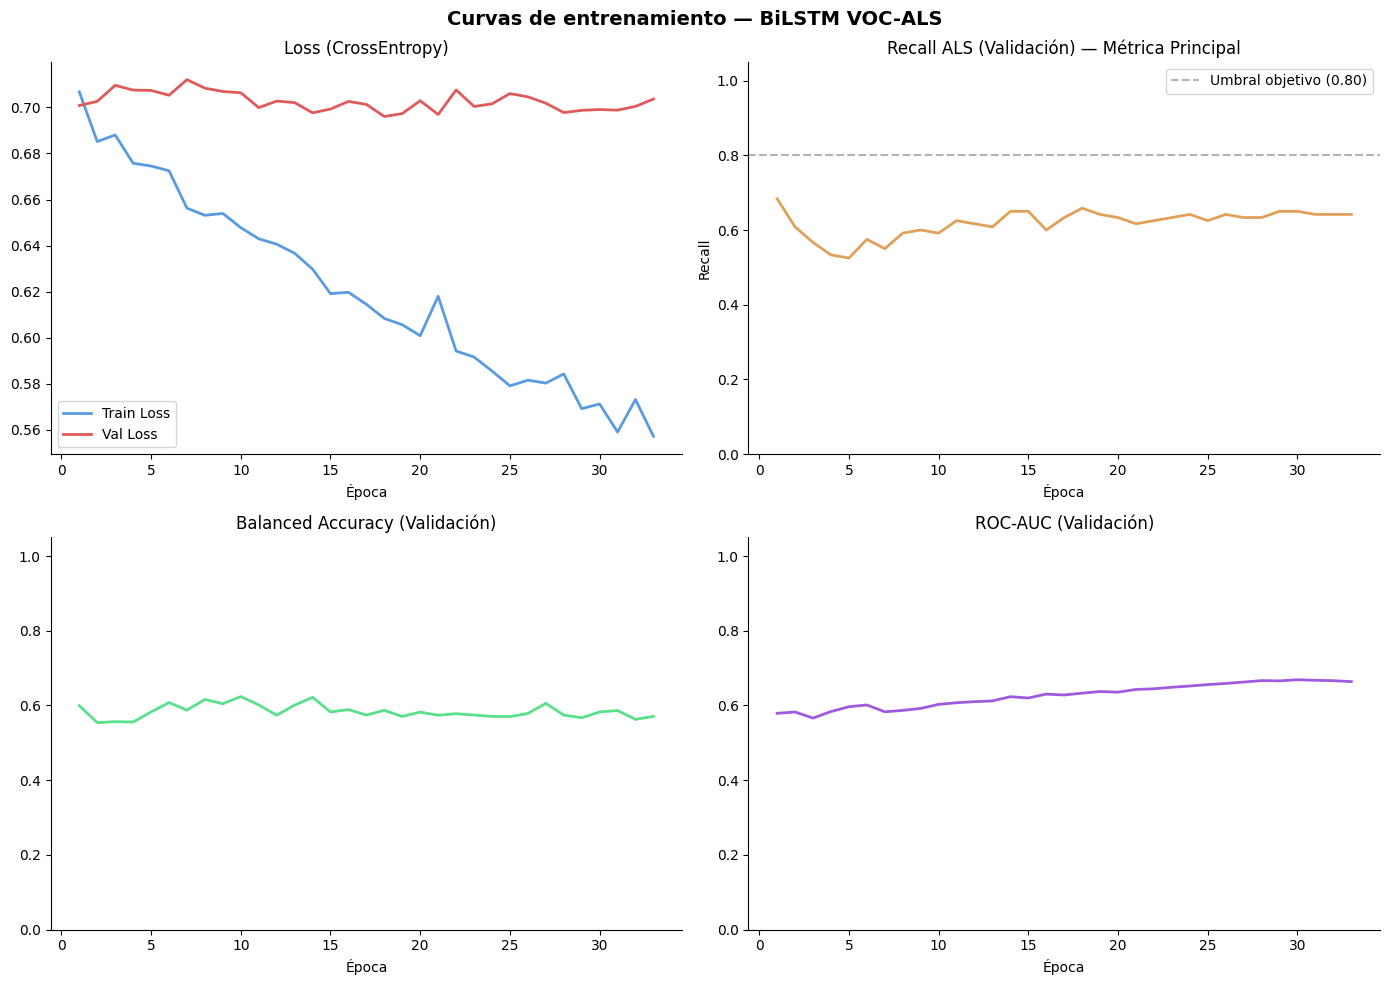

Figura guardada: 05_curvas_entrenamiento.png


In [18]:
# Curvas de entrenamiento 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Curvas de entrenamiento — BiLSTM VOC-ALS",
             fontsize=14, fontweight="bold")

epochs = history["epoch"]

# Loss
axes[0, 0].plot(epochs, history["train_loss"], label="Train Loss", color="#5A9BE0", lw=2)
axes[0, 0].plot(epochs, history["val_loss"],   label="Val Loss",   color="#E05A5A", lw=2)
axes[0, 0].set_title("Loss (CrossEntropy)")
axes[0, 0].set_xlabel("Época")
axes[0, 0].legend()
axes[0, 0].spines[["top", "right"]].set_visible(False)

# Recall ALS
axes[0, 1].plot(epochs, history["val_recall_als"], color="#E0A05A", lw=2)
axes[0, 1].axhline(0.8, ls="--", color="gray", alpha=0.6, label="Umbral objetivo (0.80)")
axes[0, 1].set_title("Recall ALS (Validación) — Métrica Principal")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Recall")
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1.05])
axes[0, 1].spines[["top", "right"]].set_visible(False)

# Balanced Accuracy
axes[1, 0].plot(epochs, history["val_balanced_acc"], color="#5AE08A", lw=2)
axes[1, 0].set_title("Balanced Accuracy (Validación)")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].spines[["top", "right"]].set_visible(False)

# ROC-AUC
axes[1, 1].plot(epochs, history["val_roc_auc"], color="#A05AE0", lw=2)
axes[1, 1].set_title("ROC-AUC (Validación)")
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "05_curvas_entrenamiento.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

# Registrar en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. EVALUACIÓN EN VALIDATION</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La evaluación en Validation Set permite estimar el rendimiento del modelo sobre datos que, aunque no se han utilizado directamente para actualizar los pesos, sí han influido en decisiones de diseño como el early stopping, la selección de hiperparámetros y el checkpointing del mejor modelo. Por ello, las métricas obtenidas en validación constituyen una estimación <b>optimista</b> del rendimiento real. Comparar estas métricas con las obtenidas posteriormente en test permite cuantificar el grado de sobreajuste indirecto al conjunto de validación: una diferencia pequeña entre ambas indica que las decisiones de diseño no han introducido un sesgo significativo, mientras que una degradación notable en test sugiere que el proceso de selección ha capturado ruido específico del split de validación.
    </span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Carga del mejor modelo</span>
</div>

In [19]:
# Restauración del mejor checkpoint 
checkpoint = torch.load(best_model_path, map_location=DEVICE)

model_eval = BiLSTMClassifier(
    input_size    = N_MELS,
    hidden_size   = HIDDEN_SIZE,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT,
    bidirectional = BIDIRECTIONAL,
    num_classes   = 2,
).to(DEVICE)

model_eval.load_state_dict(checkpoint["model_state"])
model_eval.eval()

print(f"Mejor checkpoint restaurado:")
print(f"  Época guardada : {checkpoint['epoch']}")
print(f"  Val loss       : {checkpoint['val_loss']:.4f}")
print(f"  Val métricas   : {checkpoint['val_metrics']}")

Mejor checkpoint restaurado:
  Época guardada : 18
  Val loss       : 0.6960
  Val métricas   : {'balanced_accuracy': 0.5869791666666666, 'recall_als': 0.6583333333333333, 'recall_hc': 0.515625, 'roc_auc': 0.6330729166666667}


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 18. Evaluación completa en Validation Set</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se evalúa el mejor modelo (checkpoint con menor val_loss) sobre el conjunto de validación completo, replicando el mismo pipeline de inferencia que se aplicará después sobre test. Aunque estas métricas ya se observaron de forma parcial durante el entrenamiento (época a época), aquí se recalculan con el modelo final restaurado para garantizar coherencia con la evaluación en test. La comparación muestra-sujeto en validación permite además verificar que la agregación por sujeto no introduce sesgos inesperados antes de aplicarla sobre datos completamente no vistos.
    </span>
</div>


In [20]:
# Evaluación en Validation
val_loss_eval, val_preds, val_labels, val_probs = eval_epoch(
    model_eval, val_loader, criterion, DEVICE
)

val_metrics_eval = compute_metrics(val_labels, val_preds, val_probs)

print("\nResultados en Validation Set")
print(f"  Val Loss            : {val_loss_eval:.4f}")
print(f"  Recall ALS          : {val_metrics_eval['recall_als']:.4f}  ← Métrica principal")
print(f"  Recall HC           : {val_metrics_eval['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {val_metrics_eval['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {val_metrics_eval['roc_auc']:.4f}")
print()
print("Informe de clasificación completo")
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

# Registrar métricas de validation en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({
        "val_loss_eval":      val_loss_eval,
        "val_recall_als":     val_metrics_eval["recall_als"],
        "val_recall_hc":      val_metrics_eval["recall_hc"],
        "val_balanced_acc":   val_metrics_eval["balanced_accuracy"],
        "val_roc_auc_eval":   val_metrics_eval["roc_auc"],
    })


Resultados en Validation Set
  Val Loss            : 0.6960
  Recall ALS          : 0.6583  ← Métrica principal
  Recall HC           : 0.5156
  Balanced Accuracy   : 0.5870
  ROC-AUC             : 0.6331

Informe de clasificación completo
              precision    recall  f1-score   support

          HC       0.45      0.52      0.48        64
         ALS       0.72      0.66      0.69       120

    accuracy                           0.61       184
   macro avg       0.58      0.59      0.58       184
weighted avg       0.62      0.61      0.61       184



In [21]:
@torch.no_grad()
def evaluate_by_subject(model, dataset, test_records, device, batch_size=32):
    """
    Evalúa agregando predicciones a nivel de sujeto.
    Media de P(ALS) sobre todas las grabaciones del mismo sujeto.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)
 
    all_probs = []
    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_l = batch_l.to(device)
        logits, _ = model(batch_x, batch_l)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().tolist())
 
    sample_df = pd.DataFrame({
        "subject_id": [r["subject_id"] for r in test_records],
        "task":       [r["task"]       for r in test_records],
        "label":      [r["label"]      for r in test_records],
        "prob_als":   all_probs,
    })
 
    subject_df = sample_df.groupby("subject_id").agg(
        label    = ("label",    "first"),
        prob_als = ("prob_als", "mean"),
        n_tasks  = ("task",     "count"),
        prob_std = ("prob_als", "std"),
    ).reset_index()
 
    subject_df["pred"] = (subject_df["prob_als"] >= 0.5).astype(int)
    subject_df["prob_std"] = subject_df["prob_std"].fillna(0)
 
    subj_labels = subject_df["label"].values
    subj_preds  = subject_df["pred"].values
    subj_probs  = subject_df["prob_als"].values
 
    metrics = {
        "n_subjects":        len(subject_df),
        "balanced_accuracy": balanced_accuracy_score(subj_labels, subj_preds),
        "recall_als":        recall_score(subj_labels, subj_preds, pos_label=1, zero_division=0),
        "recall_hc":         recall_score(subj_labels, subj_preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(subj_labels, subj_probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
 
    return subject_df, metrics

# Evaluación a nivel de sujeto — Validation Set
val_subject_df, val_subject_metrics = evaluate_by_subject(
    model_eval, val_dataset, val_data, DEVICE
)

print("═" * 65)
print("  EVALUACIÓN A NIVEL DE SUJETO (Validation Set)")
print("═" * 65)
print(f"  Sujetos evaluados   : {val_subject_metrics['n_subjects']}")
print(f"  Recall ALS          : {val_subject_metrics['recall_als']:.4f}  ← Métrica principal")
print(f"  Recall HC           : {val_subject_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {val_subject_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {val_subject_metrics['roc_auc']:.4f}")
print("═" * 65)

print("\nDetalle por sujeto:")
print(val_subject_df.to_string(index=False))

print("\n" + "─" * 65)
print("  COMPARATIVA: Muestra vs Sujeto")
print("─" * 65)
print(f"  {'Métrica':<25} {'Muestra':>10} {'Sujeto':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10}")
for metric_name in ["recall_als", "recall_hc", "balanced_accuracy", "roc_auc"]:
    sample_val  = val_metrics_eval[metric_name]
    subject_val = val_subject_metrics[metric_name]
    print(f"  {metric_name:<25} {sample_val:>10.4f} {subject_val:>10.4f}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({
        "val_subj_recall_als":   val_subject_metrics["recall_als"],
        "val_subj_recall_hc":    val_subject_metrics["recall_hc"],
        "val_subj_balanced_acc": val_subject_metrics["balanced_accuracy"],
        "val_subj_roc_auc":      val_subject_metrics["roc_auc"],
    })
    print("\n✓ Métricas a nivel de sujeto (val) registradas en MLflow.")

═════════════════════════════════════════════════════════════════
  EVALUACIÓN A NIVEL DE SUJETO (Validation Set)
═════════════════════════════════════════════════════════════════
  Sujetos evaluados   : 23
  Recall ALS          : 0.7333  ← Métrica principal
  Recall HC           : 0.5000
  Balanced Accuracy   : 0.6167
  ROC-AUC             : 0.6667
═════════════════════════════════════════════════════════════════

Detalle por sujeto:
subject_id  label  prob_als  n_tasks  prob_std  pred
     CT018      0  0.447840        8  0.169629     0
     CT020      0  0.386932        8  0.214490     0
     CT030      0  0.574795        8  0.088121     1
     CT046      0  0.580348        8  0.183283     1
     CT051      0  0.509233        8  0.129966     1
     CT057      0  0.384216        8  0.214868     0
     CT059      0  0.387444        8  0.160499     0
     CT060      0  0.576426        8  0.131600     1
     PZ003      1  0.416857        8  0.134335     0
     PZ022      1  0.515997    

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 19. Matriz de confusión</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La matriz de confusión en validación permite inspeccionar la distribución de errores del modelo sobre el split que ha guiado las decisiones de entrenamiento. Su comparación directa con la matriz de test revelará si el patrón de errores (proporción relativa de FN vs FP) se mantiene estable entre particiones o si el modelo ha aprendido artefactos específicos del split de validación. Una distribución de errores consistente entre ambas matrices refuerza la confianza en la generalizabilidad del modelo.
    </span>
</div>


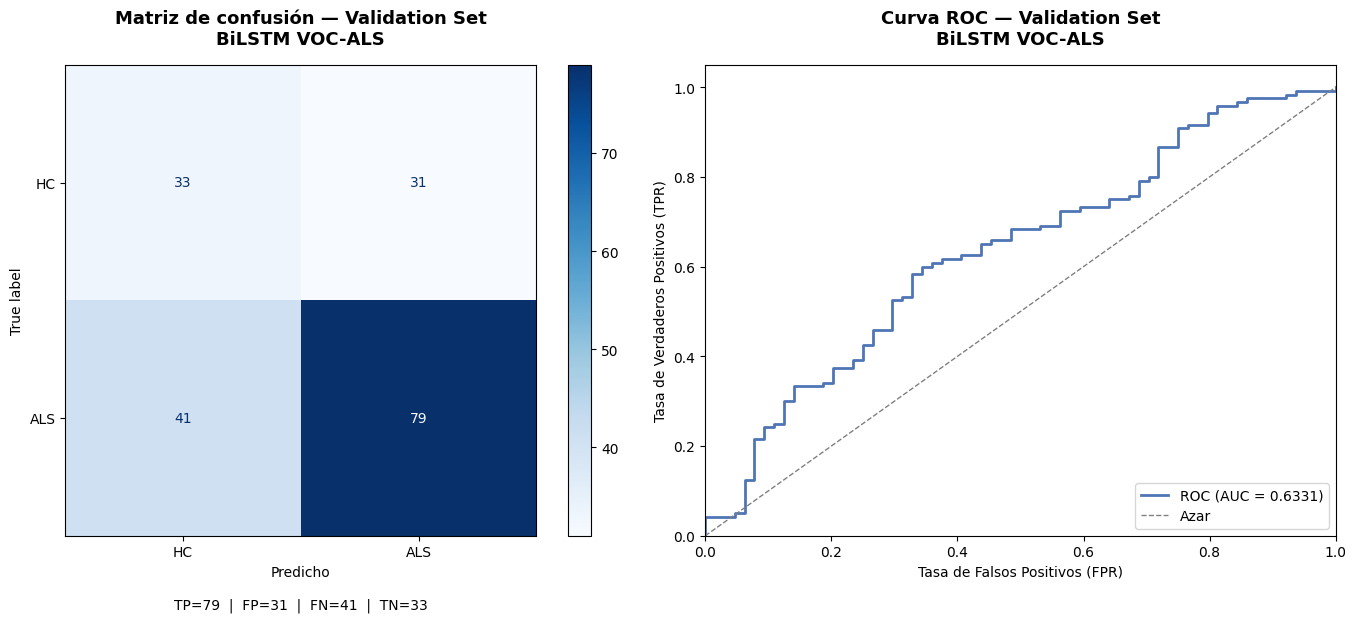

Figura guardada: 06_matriz_confusion_roc_val.png


In [22]:
# Matriz de confusión + Curva ROC — Validation Set (subplots)
cm_val = confusion_matrix(val_labels, val_preds)
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = roc_auc_score(val_labels, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Matriz de confusión ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap="Blues", values_format="d")
axes[0].set_title("Matriz de confusión — Validation Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
tn, fp, fn, tp = cm_val.ravel()
axes[0].set_xlabel(f"Predicho\n\nTP={tp}  |  FP={fp}  |  FN={fn}  |  TN={tn}",
                   fontsize=10)

# --- Subplot 2: Curva ROC ---
axes[1].plot(fpr_val, tpr_val, color="#4F75B6", lw=2,
             label=f"ROC (AUC = {roc_auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
axes[1].set_title("Curva ROC — Validation Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
fig_path = FIGS_PATH / "06_matriz_confusion_roc_val.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Curva ROC y distribución de probabilidades</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La curva ROC y la distribución de probabilidades predichas en validación proporcionan una referencia calibrada para interpretar los resultados en test. El AUC en validación establece el techo de rendimiento esperado: una caída significativa del AUC en test indicaría sobreajuste al split de validación. Asimismo, comparar las distribuciones de P(ALS) entre ambas particiones permite verificar si el modelo mantiene una separación similar entre clases o si la confianza de las predicciones se degrada en datos completamente no vistos. El umbral óptimo de Youden calculado aquí puede además contrastarse con el obtenido en test para evaluar la estabilidad del punto de operación del clasificador.
    </span>
</div>


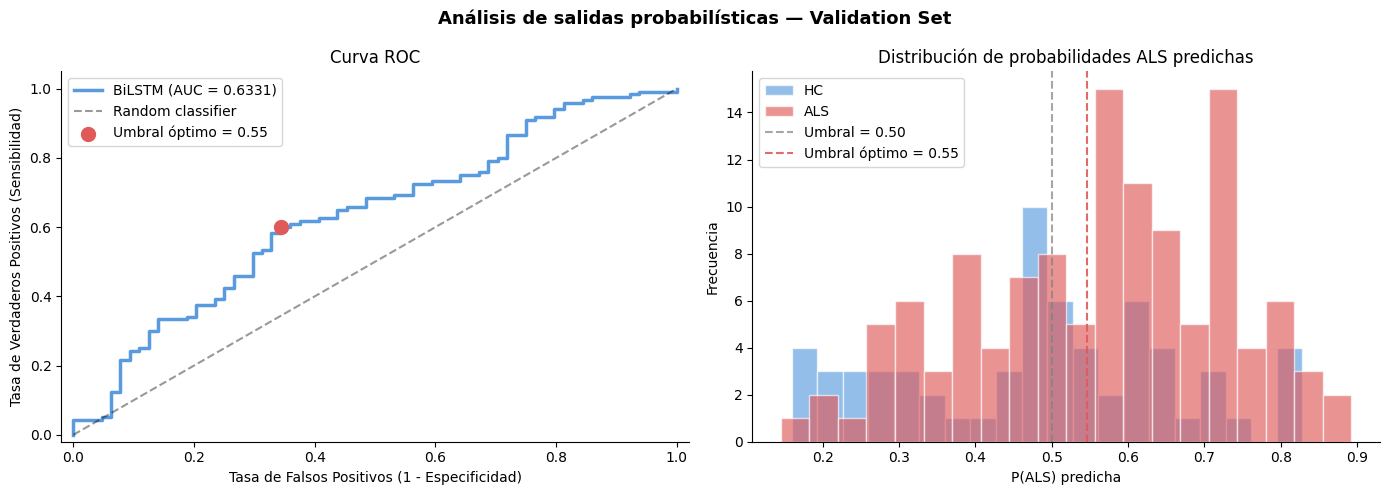

Figura guardada: 07_roc_y_distribuciones_val.png
Umbral óptimo de Youden (val): 0.5458


In [23]:
# Curva ROC — Validation Set
fpr_val, tpr_val, thresholds_val = roc_curve(val_labels, val_probs)
auc_score_val                    = val_metrics_eval["roc_auc"]

# Punto de operación óptimo (maximiza TPR - FPR)
j_scores_val  = tpr_val - fpr_val
opt_idx_val   = np.argmax(j_scores_val)
opt_thresh_val = thresholds_val[opt_idx_val]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de salidas probabilísticas — Validation Set",
             fontsize=13, fontweight="bold")

# ROC Curve
ax = axes[0]
ax.plot(fpr_val, tpr_val, color="#5A9BE0", lw=2.5, label=f"BiLSTM (AUC = {auc_score_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random classifier")
ax.scatter(fpr_val[opt_idx_val], tpr_val[opt_idx_val], color="#E05A5A", s=100, zorder=5,
            label=f"Umbral óptimo = {opt_thresh_val:.2f}")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC")
ax.legend()
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.spines[["top", "right"]].set_visible(False)

# Distribución de probabilidades por clase
ax = axes[1]
als_probs_val = val_probs[val_labels == 1]
hc_probs_val  = val_probs[val_labels == 0]

ax.hist(hc_probs_val,  bins=20, alpha=0.65, color="#5A9BE0", label="HC",  edgecolor="white")
ax.hist(als_probs_val, bins=20, alpha=0.65, color="#E05A5A", label="ALS", edgecolor="white")
ax.axvline(0.5,            ls="--", color="gray",   alpha=0.7, label="Umbral = 0.50")
ax.axvline(opt_thresh_val, ls="--", color="#E05A5A", alpha=0.9,
            label=f"Umbral óptimo = {opt_thresh_val:.2f}")
ax.set_xlabel("P(ALS) predicha")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades ALS predichas")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "07_roc_y_distribuciones_val.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")
print(f"Umbral óptimo de Youden (val): {opt_thresh_val:.4f}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))
    mlflow.log_metric("optimal_threshold_youden_val", opt_thresh_val)

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 6. EVALUACIÓN EN TEST</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La evaluación en Test Set constituye la estimación definitiva del rendimiento del modelo sobre datos no vistos. Es fundamental que este bloque se ejecute <b>una única vez</b>, después de haber finalizado completamente la selección de hiperparámetros y arquitectura. Cualquier modificación del modelo tras ver los resultados de test introduce data leakage de test, invalidando la estimación de rendimiento.
<br><br>
Se carga el <b>mejor modelo</b> guardado durante el entrenamiento (el checkpoint con menor val_loss), no el modelo al final del bucle. Esta distinción es relevante cuando el entrenamiento continúa después del mínimo de val_loss antes de que se active el early stopping.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Evaluación completa en Test Set</span>
</div>

In [24]:
# Evaluación en Test 
test_loss, test_preds, test_labels, test_probs = eval_epoch(
    model_eval, test_loader, criterion, DEVICE
)

test_metrics = compute_metrics(test_labels, test_preds, test_probs)

print("\nResultados en Test Set")
print(f"  Test Loss           : {test_loss:.4f}")
print(f"  Recall ALS          : {test_metrics['recall_als']:.4f}  ← Métrica principal")
print(f"  Recall HC           : {test_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {test_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {test_metrics['roc_auc']:.4f}")
print()
print("Informe de clasificación completo")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Registrar métricas de test en MLflow
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({
        "test_loss":         test_loss,
        "test_recall_als":   test_metrics["recall_als"],
        "test_recall_hc":    test_metrics["recall_hc"],
        "test_balanced_acc": test_metrics["balanced_accuracy"],
        "test_roc_auc":      test_metrics["roc_auc"],
    })


Resultados en Test Set
  Test Loss           : 0.6571
  Recall ALS          : 0.6172  ← Métrica principal
  Recall HC           : 0.5893
  Balanced Accuracy   : 0.6032
  ROC-AUC             : 0.7045

Informe de clasificación completo
              precision    recall  f1-score   support

          HC       0.40      0.59      0.48        56
         ALS       0.77      0.62      0.69       128

    accuracy                           0.61       184
   macro avg       0.59      0.60      0.58       184
weighted avg       0.66      0.61      0.62       184



In [25]:
subject_df, subject_metrics = evaluate_by_subject(
    model_eval, test_dataset, test_data, DEVICE
)
 
print("═" * 65)
print("  EVALUACIÓN A NIVEL DE SUJETO (Test Set)")
print("═" * 65)
print(f"  Sujetos evaluados   : {subject_metrics['n_subjects']}")
print(f"  Recall ALS          : {subject_metrics['recall_als']:.4f}  ← Métrica principal")
print(f"  Recall HC           : {subject_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {subject_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {subject_metrics['roc_auc']:.4f}")
print("═" * 65)
 
print("\nDetalle por sujeto:")
print(subject_df.to_string(index=False))
 
print("\n" + "─" * 65)
print("  COMPARATIVA: Muestra vs Sujeto")
print("─" * 65)
print(f"  {'Métrica':<25} {'Muestra':>10} {'Sujeto':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10}")
for metric_name in ["recall_als", "recall_hc", "balanced_accuracy", "roc_auc"]:
    sample_val  = test_metrics[metric_name]
    subject_val = subject_metrics[metric_name]
    print(f"  {metric_name:<25} {sample_val:>10.4f} {subject_val:>10.4f}")
 
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({
        "test_subj_recall_als":   subject_metrics["recall_als"],
        "test_subj_recall_hc":    subject_metrics["recall_hc"],
        "test_subj_balanced_acc": subject_metrics["balanced_accuracy"],
        "test_subj_roc_auc":      subject_metrics["roc_auc"],
    })
    print("\n✓ Métricas a nivel de sujeto registradas en MLflow.")

═════════════════════════════════════════════════════════════════
  EVALUACIÓN A NIVEL DE SUJETO (Test Set)
═════════════════════════════════════════════════════════════════
  Sujetos evaluados   : 23
  Recall ALS          : 0.7500  ← Métrica principal
  Recall HC           : 0.5714
  Balanced Accuracy   : 0.6607
  ROC-AUC             : 0.7143
═════════════════════════════════════════════════════════════════

Detalle por sujeto:
subject_id  label  prob_als  n_tasks  prob_std  pred
     CT014      0  0.492013        8  0.151413     0
     CT019      0  0.381163        8  0.127581     0
     CT023      0  0.480997        8  0.280463     0
     CT053      0  0.574566        8  0.175432     1
     CT066      0  0.509873        8  0.151685     1
     CT067      0  0.446587        8  0.215534     0
     CT069      0  0.560744        8  0.224446     1
     PZ004      1  0.432452        8  0.185150     0
     PZ016      1  0.753522        8  0.112658     1
     PZ025      1  0.541459        8 

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Matriz de confusión</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La matriz de confusión desagrega los resultados en cuatro categorías clínicamente interpretables. En el contexto de cribado de ALS:

<ul>
<li><b>Verdaderos Positivos (TP):</b> pacientes ALS detectados correctamente. Permiten inicio temprano de tratamiento.</li>
<li><b>Falsos Negativos (FN):</b> pacientes ALS clasificados como HC. Error de mayor coste clínico: el paciente pierde acceso a intervención temprana.</li>
<li><b>Falsos Positivos (FP):</b> controles HC clasificados como ALS. Genera angustia innecesaria y pruebas adicionales costosas, pero el coste clínico es menor que el FN.</li>
<li><b>Verdaderos Negativos (TN):</b> controles HC correctamente identificados.</li>
</ul>

Esta asimetría de costes justifica la priorización del Recall ALS como métrica principal frente a la accuracy o el F1-score balanceado.
    </span>
</div>

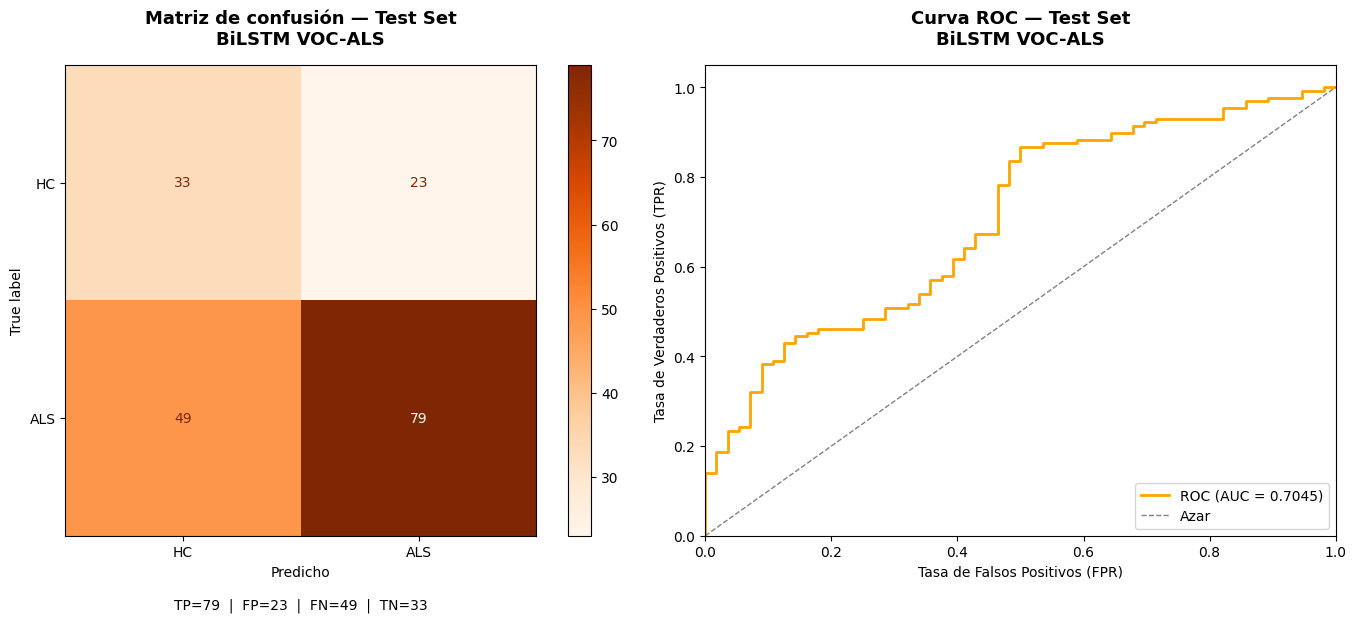

Figura guardada: 06_matriz_confusion_roc_test.png


In [26]:
# Matriz de confusión + Curva ROC (subplots)
cm = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap="Oranges", values_format="d")
axes[0].set_title("Matriz de confusión — Test Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"Predicho\n\nTP={tp}  |  FP={fp}  |  FN={fn}  |  TN={tn}",
                   fontsize=10)

# Subplot 2: Curva ROC 
axes[1].plot(fpr, tpr, color="#ffa500", lw=2,
             label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
axes[1].set_title("Curva ROC — Test Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
fig_path = FIGS_PATH / "06_matriz_confusion_roc_test.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Curva ROC y distribución de probabilidades</span>
</div>

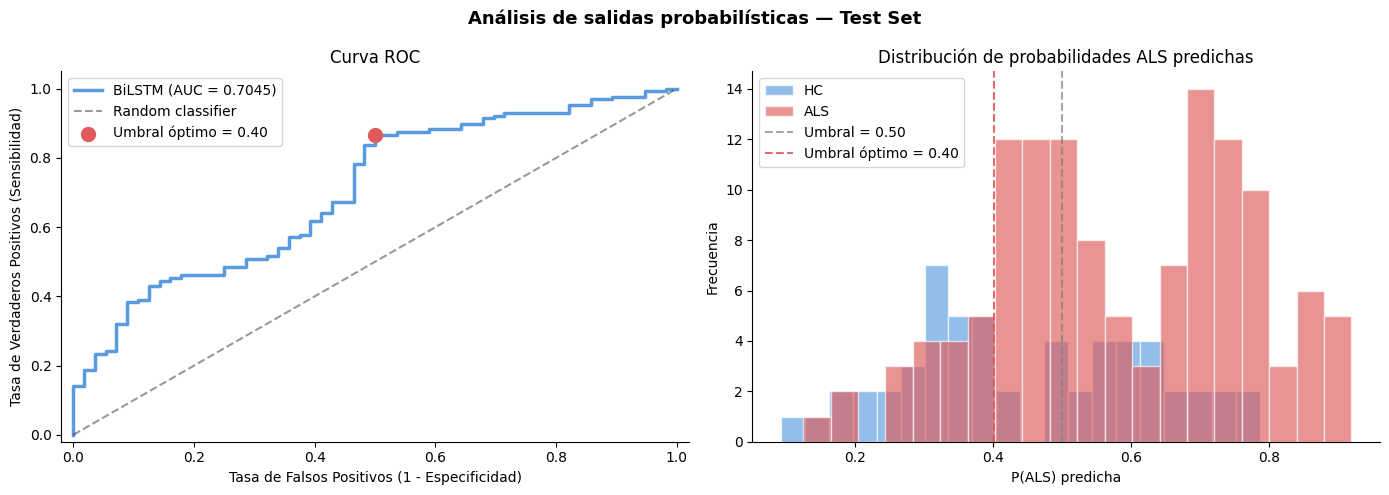

Figura guardada: 07_roc_y_distribuciones.png
Umbral óptimo de Youden: 0.4009


In [27]:
# Curva ROC  
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
auc_score            = test_metrics["roc_auc"]

# Punto de operación óptimo (maximiza TPR - FPR)
j_scores  = tpr - fpr
opt_idx   = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de salidas probabilísticas — Test Set",
             fontsize=13, fontweight="bold")

# ROC Curve
ax = axes[0]
ax.plot(fpr, tpr, color="#5A9BE0", lw=2.5, label=f"BiLSTM (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random classifier")
ax.scatter(fpr[opt_idx], tpr[opt_idx], color="#E05A5A", s=100, zorder=5,
            label=f"Umbral óptimo = {opt_thresh:.2f}")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC")
ax.legend()
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.spines[["top", "right"]].set_visible(False)

# Distribución de probabilidades por clase
ax = axes[1]
als_probs = test_probs[test_labels == 1]
hc_probs  = test_probs[test_labels == 0]

ax.hist(hc_probs,  bins=20, alpha=0.65, color="#5A9BE0", label="HC",  edgecolor="white")
ax.hist(als_probs, bins=20, alpha=0.65, color="#E05A5A", label="ALS", edgecolor="white")
ax.axvline(0.5,        ls="--", color="gray",   alpha=0.7, label="Umbral = 0.50")
ax.axvline(opt_thresh, ls="--", color="#E05A5A", alpha=0.9,
            label=f"Umbral óptimo = {opt_thresh:.2f}")
ax.set_xlabel("P(ALS) predicha")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades ALS predichas")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "07_roc_y_distribuciones.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")
print(f"Umbral óptimo de Youden: {opt_thresh:.4f}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))
    mlflow.log_metric("optimal_threshold_youden", opt_thresh)

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 7. EXPLICABILIDAD</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La explicabilidad es un requisito imprescindible en aplicaciones clínicas de Deep Learning. Un modelo de caja negra que alcanza un ROC-AUC de 0.85 pero no permite identificar qué características de la señal de voz utiliza para clasificar difícilmente será adoptado en la práctica clínica, por dos razones:

<ol>
<li><b>Razón epistemológica:</b> no es posible verificar si el modelo está aprendiendo biomarcadores acústicos genuinamente asociados a la ALS o si está explotando confusores (diferencias de calidad de grabación, edad, sexo) sin relación causal con la enfermedad.</li>
<li><b>Razón regulatoria:</b> los sistemas de apoyo a la decisión clínica requieren justificación interpretable de sus predicciones para ser certificados bajo normativas como MDR (Medical Device Regulation) en Europa.</li>
</ol>

Este bloque implementa dos técnicas complementarias de explicabilidad:

<ul>
<li><b>Saliency maps (gradiente de entrada):</b> identifican qué regiones del espectrograma (bins Mel × frames) tienen mayor influencia sobre la predicción del modelo, calculando el gradiente de la clase predicha respecto a la entrada.</li>
<li><b>PCA y t-SNE de embeddings:</b> visualizan el espacio de representación aprendido por la BiLSTM en dimensiones reducidas, evaluando si el modelo ha construido una representación que separa ALS de HC de forma geométricamente coherente.</li>
</ul>
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 24. Saliency maps sobre espectrogramas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los <b>saliency maps</b> son la técnica de explicabilidad más directamente aplicable a redes recurrentes con entrada de espectrograma. La idea es sencilla: si se calcula el gradiente de la puntuación de la clase correcta respecto a cada píxel del espectrograma de entrada, el valor absoluto de ese gradiente indica cuánto cambiaría la predicción si se perturbara levemente ese píxel. Regiones con gradiente alto son las más "relevantes" para la decisión del modelo.
<br><br>
Formalmente, dado el espectrograma de entrada <b>X</b> ∈ ℝ<sup>T×F</sup> y la puntuación de la clase c, el saliency map es:
<br><br>
<code>S = |∂ score_c / ∂ X|</code>
<br><br>
Desde el punto de vista clínico, esperamos que las regiones más salientes en pacientes ALS correspondan a:
<ul>
<li><b>Bandas de frecuencia media-baja (150-1000 Hz):</b> región de los formantes F1 y F2, cuya inestabilidad es característica de la disartria flácido-espástica de la ALS.</li>
<li><b>Regiones de baja energía al inicio y fin de la fonación:</b> la incapacidad de mantener una fonación sostenida produce flancos de ataque y decaimiento anormales.</li>
<li><b>Bandas de alta frecuencia (>4000 Hz):</b> el ruido espectral aperiódico, asociado a voz aérea, puede ser más saliente en ALS que en HC.</li>
</ul>
    </span>
</div>

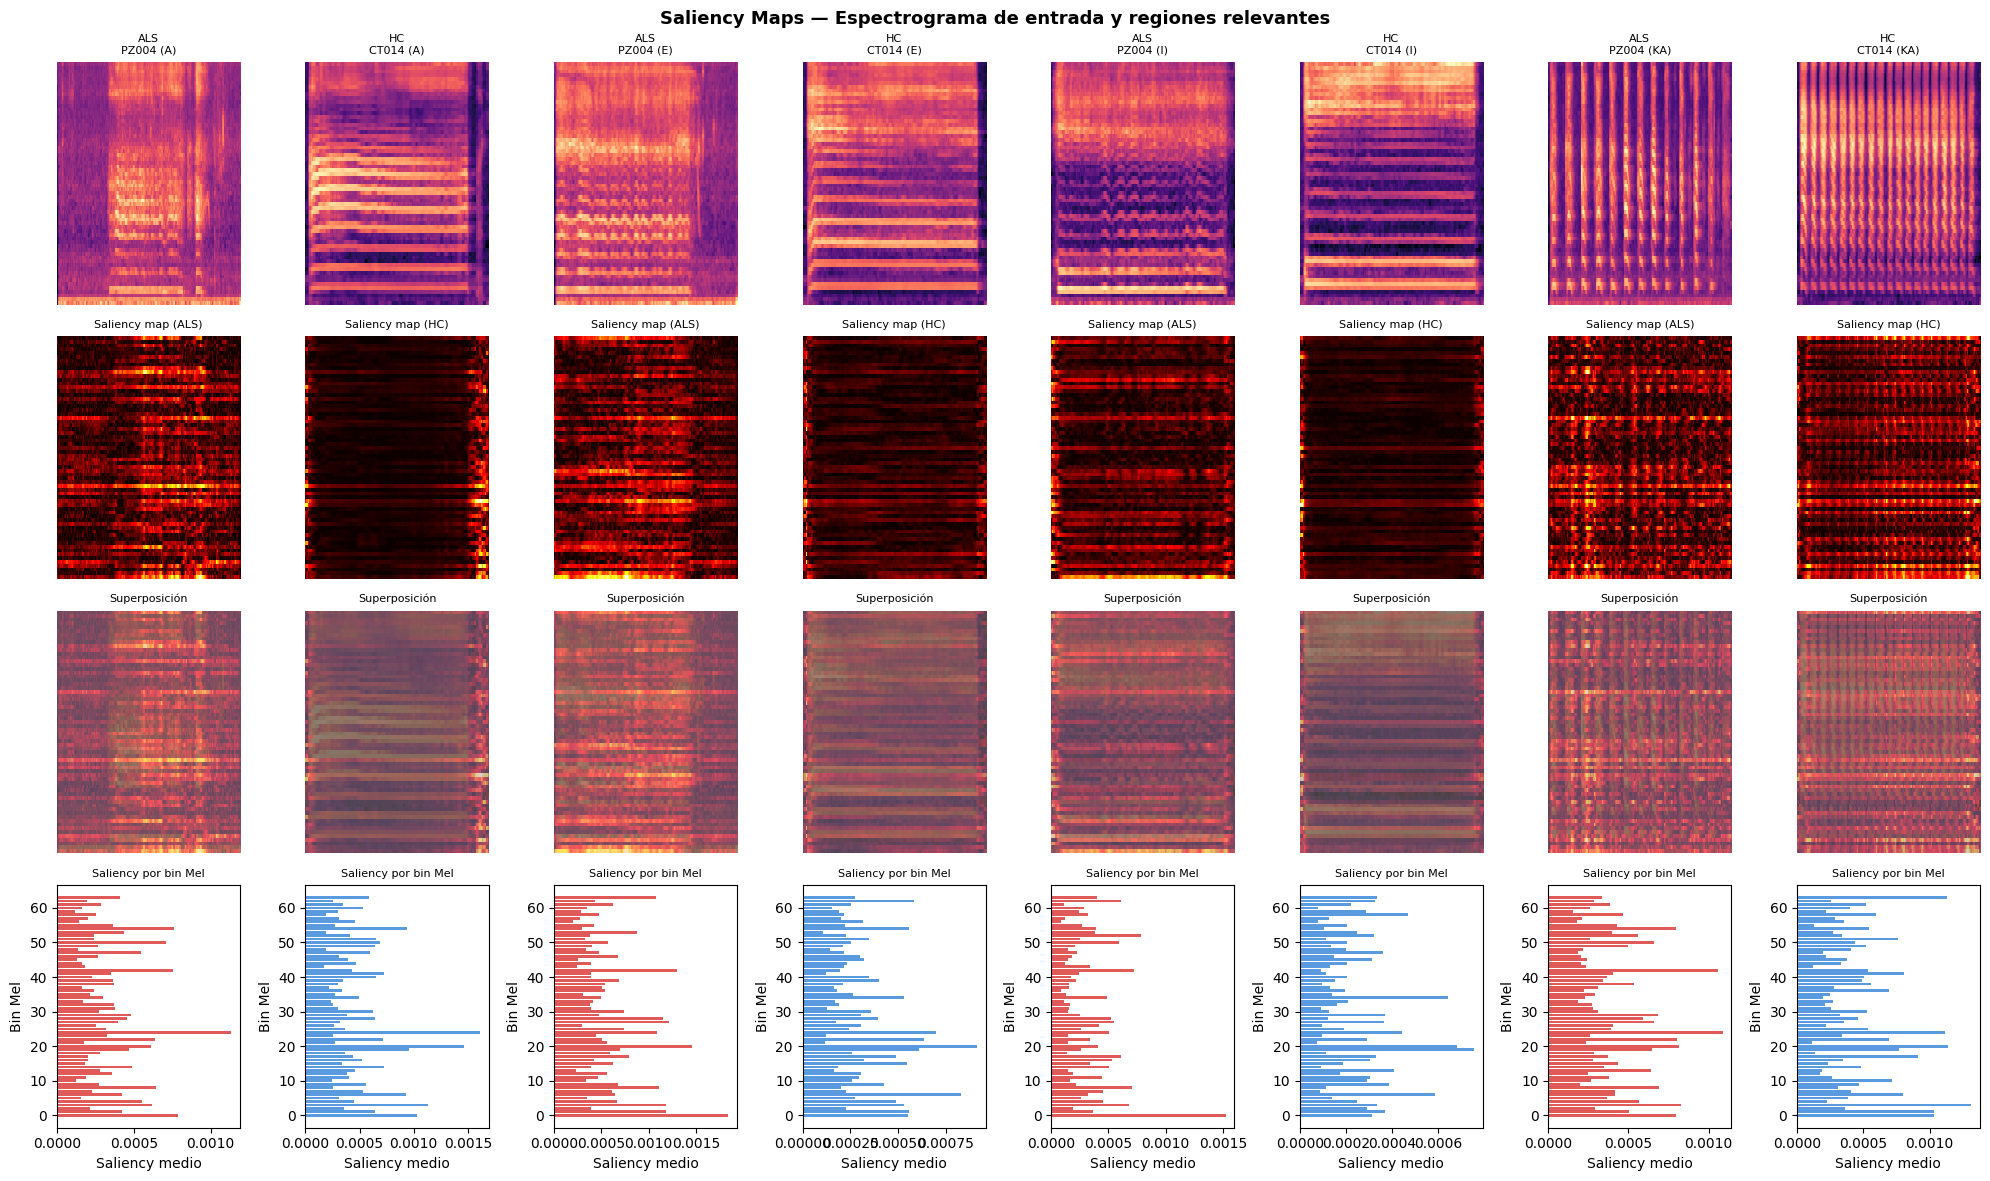

Figura guardada: 08_saliency_maps.png


In [28]:
def compute_saliency_map(model, tensor: torch.Tensor, length: torch.Tensor,
                         target_class: int, device) -> np.ndarray:
    """
    Calcula el saliency map de un espectrograma para una clase objetivo.

    En GPU, el backward de LSTM/RNN con cuDNN falla en modo eval. Para evitarlo,
    se fuerza temporalmente la ejecución sin cuDNN durante el cálculo del gradiente.

    Args:
        model:        Modelo BiLSTM entrenado.
        tensor:       Tensor (T, N_MELS) con el espectrograma de una muestra.
        length:       Tensor escalar con la longitud real de la secuencia.
        target_class: Índice de clase objetivo (0=HC, 1=ALS).
        device:       Dispositivo de cómputo.

    Returns:
        saliency:     Array (T, N_MELS) con la magnitud del gradiente.
    """
    was_training = model.training
    model.eval()

    x = tensor.unsqueeze(0).to(device)
    x.requires_grad_(True)
    l = length.unsqueeze(0).to(device)

    model.zero_grad(set_to_none=True)

    if device.type == "cuda":
        with torch.backends.cudnn.flags(enabled=False):
            logits, _ = model(x, l)
            score = logits[0, target_class]
            score.backward()
    else:
        logits, _ = model(x, l)
        score = logits[0, target_class]
        score.backward()

    saliency = x.grad.detach().abs().squeeze(0).cpu().numpy()

    if was_training:
        model.train()

    return saliency


# Visualización de saliency maps 
n_examples  = 4
als_records = [r for r in test_data if r["label"] == 1][:n_examples]
hc_records  = [r for r in test_data if r["label"] == 0][:n_examples]

fig, axes = plt.subplots(4, n_examples * 2, figsize=(20, 12))
fig.suptitle("Saliency Maps — Espectrograma de entrada y regiones relevantes",
             fontsize=13, fontweight="bold")

def get_tensor_and_length(rec):
    tensor = rec["tensor"].T.float()   # (T, N_MELS)
    length = torch.tensor(rec["n_frames"], dtype=torch.long)
    return tensor, length

for i, (als_rec, hc_rec) in enumerate(zip(als_records, hc_records)):

    for j, (rec, cls_name, target_cls) in enumerate(
        [(als_rec, "ALS", 1), (hc_rec, "HC", 0)]
    ):
        col = i * 2 + j
        tensor, length = get_tensor_and_length(rec)

        # Espectrograma original
        spec = rec["tensor"].numpy()   # (N_MELS, T)
        axes[0, col].imshow(spec, aspect="auto", origin="lower",
                             cmap="magma", interpolation="nearest")
        axes[0, col].set_title(f"{cls_name}\n{rec['subject_id']} ({rec['task']})", fontsize=8)
        axes[0, col].axis("off")

        # Saliency para clase correcta
        sal = compute_saliency_map(model_eval, tensor, length, target_cls, DEVICE)
        sal_T = sal.T   # (N_MELS, T)

        axes[1, col].imshow(sal_T, aspect="auto", origin="lower",
                             cmap="hot", interpolation="nearest")
        axes[1, col].set_title(f"Saliency map ({cls_name})", fontsize=8)
        axes[1, col].axis("off")

        # Superposición
        axes[2, col].imshow(spec, aspect="auto", origin="lower",
                             cmap="magma", alpha=0.5, interpolation="nearest")
        axes[2, col].imshow(sal_T, aspect="auto", origin="lower",
                             cmap="hot", alpha=0.5, interpolation="nearest")
        axes[2, col].set_title("Superposición", fontsize=8)
        axes[2, col].axis("off")

        # Perfil de saliencia por bin Mel (promedio temporal)
        sal_freq = sal_T.mean(axis=1)   # (N_MELS,)
        axes[3, col].barh(range(N_MELS), sal_freq, color="#E05A5A" if cls_name == "ALS" else "#5A9BE0")
        axes[3, col].set_title("Saliency por bin Mel", fontsize=8)
        axes[3, col].set_xlabel("Saliency medio")
        axes[3, col].set_ylabel("Bin Mel")

plt.tight_layout()
fig_path = FIGS_PATH / "08_saliency_maps.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 25. Interpretación clínica de las regiones relevantes</span>
</div>

Saliency media por banda de frecuencia:
Banda                                      ALS         HC    ALS/HC
──────────────────────────────────────────────────────────────────────
Subgraves (< 150 Hz)                    0.0005     0.0005      1.03
Graves (150–500 Hz)                     0.0003     0.0003      0.90
Formantes F1-F2 (500–2kHz)              0.0003     0.0003      0.88
Medios-altos (2–4 kHz)                  0.0003     0.0003      0.92
Altos (> 4 kHz)                         0.0000     0.0000       inf


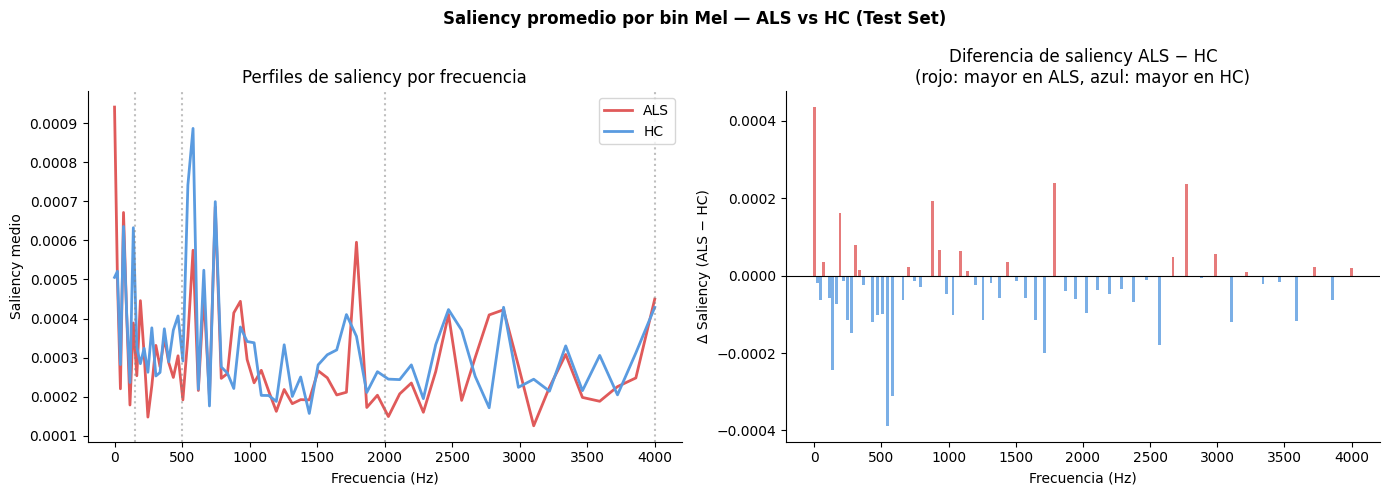

Figura guardada: 09_saliency_por_banda.png


In [29]:
# Análisis cuantitativo de saliency por banda de frecuencia 
def mel_bin_to_hz(bin_idx: int, n_mels: int = N_MELS, sr: int = SR,
                   n_fft: int = N_FFT) -> float:
    """Convierte un índice de bin Mel a frecuencia en Hz (aproximación lineal en Mel)."""
    f_min, f_max = 0, sr / 2
    mel_min  = 2595 * np.log10(1 + f_min / 700)
    mel_max  = 2595 * np.log10(1 + f_max / 700)
    mel_bins = np.linspace(mel_min, mel_max, n_mels)
    hz_bins  = 700 * (10 ** (mel_bins / 2595) - 1)
    return hz_bins[bin_idx]

# Definir bandas clínicas de interés
FREQ_BANDS = {
    "Subgraves (< 150 Hz)":        (0, 150),
    "Graves (150–500 Hz)":          (150, 500),
    "Formantes F1-F2 (500–2kHz)":  (500, 2000),
    "Medios-altos (2–4 kHz)":      (2000, 4000),
    "Altos (> 4 kHz)":             (4000, SR // 2),
}

# Calcular saliency promedio por banda para ALS y HC en test
hz_centers = np.array([mel_bin_to_hz(i) for i in range(N_MELS)])

def avg_saliency_by_band(records, target_class):
    all_sal = []
    for rec in records[:20]:   # Muestra de 20 para eficiencia
        tensor, length = get_tensor_and_length(rec)
        sal = compute_saliency_map(model_eval, tensor, length, target_class, DEVICE)
        all_sal.append(sal.T.mean(axis=1))   # (N_MELS,) — promedio temporal
    return np.mean(all_sal, axis=0)

als_test = [r for r in test_data if r["label"] == 1]
hc_test  = [r for r in test_data if r["label"] == 0]

sal_als = avg_saliency_by_band(als_test, target_class=1)
sal_hc  = avg_saliency_by_band(hc_test,  target_class=0)

print("Saliency media por banda de frecuencia:")
print(f"{'Banda':<35} {'ALS':>10} {'HC':>10}  {'ALS/HC':>8}")
print("─" * 70)

for band_name, (f_low, f_high) in FREQ_BANDS.items():
    mask  = (hz_centers >= f_low) & (hz_centers < f_high)
    s_als = sal_als[mask].mean() if mask.any() else 0.0
    s_hc  = sal_hc[mask].mean()  if mask.any() else 0.0
    ratio = s_als / s_hc if s_hc > 0 else float("inf")
    print(f"{band_name:<35} {s_als:>10.4f} {s_hc:>10.4f}  {ratio:>8.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Saliency promedio por bin Mel — ALS vs HC (Test Set)",
             fontsize=12, fontweight="bold")

ax = axes[0]
ax.plot(hz_centers, sal_als, color="#E05A5A", label="ALS", lw=2)
ax.plot(hz_centers, sal_hc,  color="#5A9BE0", label="HC",  lw=2)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Saliency medio")
ax.set_title("Perfiles de saliency por frecuencia")
ax.legend()
for f in [150, 500, 2000, 4000]:
    ax.axvline(f, ls=":", color="gray", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
diff_sal = sal_als - sal_hc
colors   = ["#E05A5A" if v > 0 else "#5A9BE0" for v in diff_sal]
ax.bar(hz_centers, diff_sal, width=hz_centers[1]-hz_centers[0], color=colors, alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Δ Saliency (ALS − HC)")
ax.set_title("Diferencia de saliency ALS − HC\n(rojo: mayor en ALS, azul: mayor en HC)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "09_saliency_por_banda.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 26. PCA y t-SNE de embeddings BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización del espacio de representación latente permite evaluar si la BiLSTM ha aprendido una representación geométricamente coherente con la tarea de clasificación. Se extraen los vectores de embedding de 256 dimensiones (salida del attention pooling, antes del clasificador MLP) para todas las muestras de test, y se reducen a 2D mediante dos técnicas complementarias:
<br><ul>
<li><b>PCA (Análisis de Componentes Principales):</b> proyección lineal que maximiza la varianza explicada. Permite identificar si la separación ALS/HC es capturada por las primeras componentes principales.</li>
<li><b>t-SNE (t-distributed Stochastic Neighbor Embedding):</b> proyección no lineal que preserva la estructura local de vecindad. Revela agrupaciones (clusters) y estructuras de manifold que la PCA no puede capturar.</li>
</ul>
Una buena separación en el espacio de embeddings indica que el modelo ha construido representaciones internas discriminativas, lo que tiene implicaciones positivas para la transferibilidad del modelo a nuevos datos y para el refinamiento mediante fine-tuning con datos adicionales.
    </span>
</div>

In [30]:
# Extracción de embeddings
@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Extrae los vectores de embedding para todas las muestras de un DataLoader."""
    model.eval()
    all_embeddings, all_labels = [], []

    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_l = batch_l.to(device)

        embeddings = model.get_embedding(batch_x, batch_l)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.extend(batch_y.tolist())

    return np.vstack(all_embeddings), np.array(all_labels)


# Extraer embeddings de los tres splits para visualización completa
train_emb, train_lbls = extract_embeddings(model_eval, train_loader, DEVICE)
val_emb,   val_lbls   = extract_embeddings(model_eval, val_loader,   DEVICE)
test_emb,  test_lbls  = extract_embeddings(model_eval, test_loader,  DEVICE)

# Concatenar para visualización conjunta
all_emb  = np.vstack([train_emb, val_emb, test_emb])
all_lbls = np.concatenate([train_lbls, val_lbls, test_lbls])
all_split = (["train"] * len(train_emb) + ["val"] * len(val_emb) +
             ["test"]  * len(test_emb))

print(f"Embeddings extraídos: {all_emb.shape}  (N, embedding_dim)")
print(f"Clases: {np.bincount(all_lbls)}")

Embeddings extraídos: (1224, 64)  (N, embedding_dim)
Clases: [408 816]


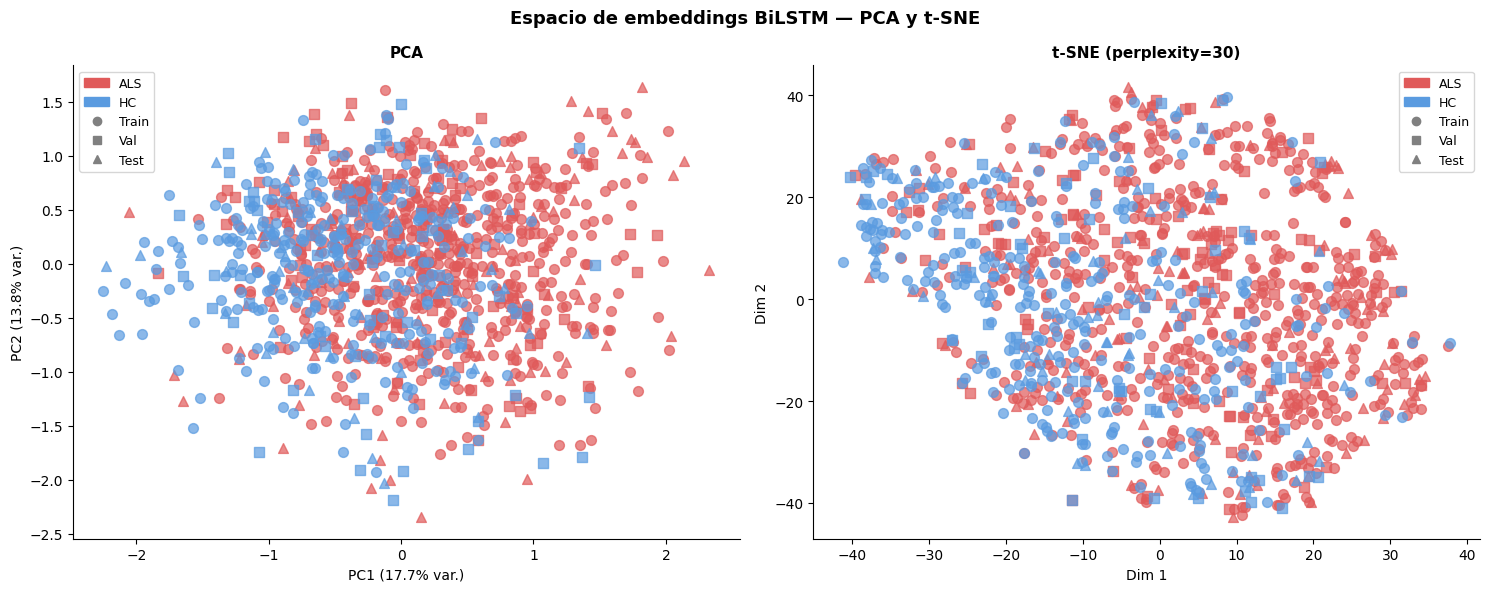

Figura guardada: 10_embeddings_pca_tsne.png


In [31]:
# PCA  
set_seed(SEED)
pca        = PCA(n_components=2, random_state=SEED)
emb_pca    = pca.fit_transform(all_emb)
var_exp    = pca.explained_variance_ratio_

# t-SNE  
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, verbose=0)
emb_tsne   = tsne.fit_transform(all_emb)

# Visualización 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Espacio de embeddings BiLSTM — PCA y t-SNE",
             fontsize=13, fontweight="bold")

palette_cls   = {1: "#E05A5A", 0: "#5A9BE0"}
palette_split = {"train": "o", "val": "s", "test": "^"}

for ax, emb, title, xlabel, ylabel in [
    (axes[0], emb_pca,  "PCA",
     f"PC1 ({var_exp[0]*100:.1f}% var.)", f"PC2 ({var_exp[1]*100:.1f}% var.)"),
    (axes[1], emb_tsne, "t-SNE (perplexity=30)", "Dim 1", "Dim 2"),
]:
    for cls_id, cls_name in [(1, "ALS"), (0, "HC")]:
        for split_name, marker in palette_split.items():
            mask = (all_lbls == cls_id) & (np.array(all_split) == split_name)
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=palette_cls[cls_id], marker=marker, alpha=0.7,
                       s=50, label=f"{cls_name}/{split_name}" if split_name == "train" else "")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

# Leyenda manual
legend_elements = [
    mpatches.Patch(color="#E05A5A", label="ALS"),
    mpatches.Patch(color="#5A9BE0", label="HC"),
    plt.Line2D([0], [0], marker="o", color="gray", ls="", label="Train"),
    plt.Line2D([0], [0], marker="s", color="gray", ls="", label="Val"),
    plt.Line2D([0], [0], marker="^", color="gray", ls="", label="Test"),
]
axes[0].legend(handles=legend_elements, loc="best", fontsize=9)
axes[1].legend(handles=legend_elements, loc="best", fontsize=9)

plt.tight_layout()
fig_path = FIGS_PATH / "10_embeddings_pca_tsne.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(fig_path))

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 27. Discusión de resultados y limitaciones</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook ha entrenado y evaluado un modelo BiLSTM con attention pooling sobre espectrogramas log-Mel a 8 kHz para la clasificación binaria ALS vs. HC, manteniendo el mismo split a nivel de sujeto utilizado en los notebooks 2 y 3 para garantizar la comparabilidad directa con los modelos clásicos. Esta versión incorpora tres cambios sustantivos respecto a iteraciones previas: el sample rate de trabajo se ha ajustado al valor nativo del dataset (8 kHz, frente a los 16 kHz upsampleados de la versión anterior), el espectrograma se ha redimensionado a 64 bandas Mel coherentes con el rango espectral disponible [0, 4000] Hz, y la arquitectura del modelo ha incorporado una capa de normalización a la entrada (<code>LayerNorm</code> sobre los 64 bins) y una capa de atención (proyección lineal 64→1 con softmax temporal) sobre los estados ocultos del BiLSTM, en sustitución del pooling implícito que se utilizaba previamente. Los resultados obtenidos muestran una mejora cuantitativa y cualitativa del modelo, y permiten una lectura más matizada del experimento.
<br>
<ul>
<li><b>Rendimiento global del modelo.</b> El BiLSTM con attention pooling alcanza en test una balanced accuracy de 0.6032 y un ROC-AUC de 0.7045 a nivel de muestra (184 segmentos), y de 0.6607 / 0.7143 a nivel de sujeto (23 sujetos). El recall ALS, métrica clínicamente prioritaria en un escenario de cribado de ELA, es de 0.6172 a nivel de muestra y de 0.7500 a nivel de sujeto. En validation, los valores son 0.5870 / 0.6331 (muestra) y 0.6167 / 0.6667 (sujeto), con un recall ALS de 0.6583 y 0.7333 respectivamente. Estos resultados representan una mejora sustancial respecto a la versión anterior del modelo (que reportaba balanced accuracy a nivel de sujeto de 0.5268 y AUC 0.6607 en test) y, por primera vez en el proyecto, sitúan al modelo profundo en niveles comparables al baseline Random Forest del Notebook 02 en términos de balanced accuracy, y claramente superiores en términos de ROC-AUC (0.7143 frente a 0.5893 del RF v1.0). La mejora es atribuible al efecto conjunto de los tres cambios introducidos en esta versión, no exclusivamente al cambio de sample rate.</li><br>

<li><b>Comportamiento durante el entrenamiento y desaparición del overfitting precoz.</b> Las curvas registradas en MLflow muestran un patrón sustancialmente más sano que en la versión anterior. El train loss desciende de forma sostenida desde 0.7067 en la primera época hasta 0.5572 en la trigésimo tercera, mientras que el val loss alcanza su mínimo (0.6960) en la <b>época 18</b>, no en la cuarta como ocurría previamente. El early stopping con paciencia 15 detiene el entrenamiento en la época 33 y restaura el checkpoint de la época 18 como mejor modelo. Esto significa que el modelo aprende durante casi veinte épocas antes de empezar a memorizar el conjunto de entrenamiento, lo cual es indicio de una capacidad efectiva mejor ajustada a la cantidad de información discriminativa presente en los datos. La brecha train-val al final del entrenamiento se mantiene en torno a 0.15 puntos, similar a la de la versión anterior, pero el hecho de que el mejor punto de generalización se alcance tan tarde es la diferencia cualitativa más relevante: el modelo no overfittea de forma instantánea, sino que tiene un margen real de aprendizaje útil.</li><br>

<li><b>Augmentation en rango aceptable.</b> La verificación cuantitativa del data augmentation reporta ahora una diferencia media respecto al original del 36.5%, frente al 64.6% de la versión anterior y un objetivo declarado del 15-30%. La cifra sigue ligeramente por encima del rango objetivo, pero ya está dentro del orden de magnitud razonable y no es destructiva. La reducción se ha conseguido manteniendo la misma combinación de transformaciones (SpecAugment ×2, ruido gaussiano, ganancia aleatoria) pero sobre espectrogramas más compactos (64 bandas en lugar de 128), lo que limita el daño relativo de cada máscara de SpecAugment. Esta mejora explica parcialmente la mayor estabilidad del entrenamiento.</li><br>

<li><b>Calibración y umbral óptimo.</b> El análisis de la distribución de probabilidades sobre validation y test sigue mostrando una concentración relativamente estrecha en torno a la frontera de decisión, pero los umbrales óptimos de Youden revelan un comportamiento asimétrico interesante: en validation el umbral óptimo es 0.5458, próximo al valor por defecto, mientras que en test desciende notablemente a 0.4009. Esta diferencia indica que sobre el test set las probabilidades del modelo están ligeramente sesgadas hacia la clase HC, y que bajar el umbral por debajo de 0.5 mejoraría la sensibilidad ALS sin penalizar excesivamente la especificidad. La existencia de una brecha de aproximadamente 14 puntos porcentuales entre los dos umbrales óptimos val-test es una señal de inestabilidad de calibración entre splits que conviene tener presente: en una aplicación real, el umbral debería ajustarse sobre validation y aplicarse sin modificación sobre el test, no optimizarse independientemente en cada conjunto.</li><br>

<li><b>Comparativa muestra vs. sujeto.</b> A diferencia de la versión anterior, en esta iteración la agregación a nivel de sujeto produce mejoras consistentes en ambos splits y en todas las métricas. En validation, el promediado mejora la balanced accuracy de 0.5870 a 0.6167, el AUC de 0.6331 a 0.6667 y el recall ALS de 0.6583 a 0.7333. En test, las mejoras son aún más marcadas: balanced accuracy 0.6032 → 0.6607, AUC 0.7045 → 0.7143, recall ALS 0.6172 → 0.7500 y recall HC 0.5893 → 0.5714 (esta última se mantiene prácticamente estable). Esta consistencia val-test, ausente en la versión anterior, sugiere que la agregación por sujeto está capturando efectivamente la reducción de ruido entre tareas vocales y no es un artefacto del split. La desviación estándar de las probabilidades por sujeto se sitúa entre 0.07 y 0.28 (con valores típicos en torno a 0.15), lo que indica que las distintas tareas vocales aportan información parcialmente complementaria y que ninguna por sí sola es dominante.</li><br>

<li><b>Interpretabilidad mediante saliency maps.</b> El análisis de saliency promedio por banda de frecuencia es ahora sustancialmente más informativo que en la versión anterior, gracias a que el rango espectral del espectrograma está limitado al contenido acústico real [0, 4000] Hz. La banda <b>subgraves (&lt;150 Hz)</b> es la única que presenta un cociente de saliency ALS/HC superior a 1 (1.03), lo que es coherente con la fisiopatología de la disartria flácido-espástica: esta banda contiene la frecuencia fundamental F0 (80-300 Hz), cuya alteración es uno de los marcadores acústicos más característicos de la afectación bulbar en ELA. Las bandas restantes muestran cocientes ligeramente inferiores a 1 (graves 0.90, formantes F1-F2 0.88, medios-altos 0.92), lo que indica que el modelo presta atención a todas ellas pero con un sesgo relativo hacia las bandas más bajas en los pacientes ALS. La banda nominalmente etiquetada como "altos (&gt;4 kHz)" presenta saliency literalmente cero en ambas clases (cociente <code>inf</code> por división), confirmando que el espectrograma a 8 kHz no contiene contenido en esa región y validando la decisión metodológica de adoptar el sample rate nativo: en la versión anterior, esa banda contribuía a la saliency con valores no nulos pese a no contener señal vocal real, lo cual era un artefacto del upsampling.</li><br>

<li><b>Espacio de embeddings.</b> La proyección de los embeddings de la última capa oculta (dimensión 64, extraídos sobre las 1224 muestras de los tres splits) mediante PCA y t-SNE muestra una segregación parcial entre las clases ALS y HC, con clusters todavía solapados pero con tendencia visible a la separación, especialmente en la proyección t-SNE. Esta mejora cualitativa respecto a la versión anterior (donde las clases aparecían completamente mezcladas) es coherente con el aumento del AUC observado en las métricas: el modelo ha aprendido a construir una representación interna en la que las dos clases ocupan regiones parcialmente distintas del espacio latente, aunque la frontera entre ellas siga siendo difusa.</li><br>

<li><b>Limitaciones que persisten.</b> Pese a las mejoras observadas, las limitaciones estructurales del experimento siguen vigentes y deben enmarcar correctamente la interpretación de los resultados: (i) el <b>tamaño muestral</b> del dataset VOC-ALS sigue siendo de 153 sujetos, con solo 23 en el conjunto de test, lo que implica que cualquier diferencia entre modelos inferior a unos 4-5 puntos porcentuales sigue estando dentro del intervalo de confianza esperable; (ii) la <b>variabilidad intra-sujeto</b> entre las ocho tareas vocales sigue siendo elevada, como muestran las desviaciones estándar de las probabilidades por sujeto, y la agregación por promedio aritmético no es necesariamente la estrategia óptima; (iii) la <b>brecha entre los umbrales de Youden de validation y test</b> (0.5458 frente a 0.4009) revela una calibración inestable entre splits que merece análisis adicional; (iv) la balanced accuracy sigue lejos de cifras clínicamente útiles, y el recall HC en test (0.5714 a nivel de sujeto) está todavía cerca del azar, lo que indica que el modelo conserva un sesgo hacia la clase mayoritaria; y (v) la mejora observada respecto a la versión anterior es resultado conjunto de tres cambios simultáneos (sample rate nativo, attention pooling y reducción de N_MELS), por lo que no es posible atribuir cuantitativamente la contribución relativa de cada uno sin un estudio de ablación específico.</li>
    </span> 
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 28. Conclusiones del notebook</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
A la luz de los resultados obtenidos y de la discusión anterior, las conclusiones operativas de este notebook son las siguientes:
<br>
<ul>
<li><b>El BiLSTM con attention pooling sobre log-Mel a 8 kHz iguala al baseline Random Forest en balanced accuracy y lo supera en ROC-AUC.</b> Con una balanced accuracy de 0.6607 y un AUC de 0.7143 en test a nivel de sujeto, el modelo profundo se sitúa por primera vez en niveles comparables al Random Forest sobre features acústicas agregadas en términos de la métrica principal, y claramente por encima en términos de capacidad de ranking (AUC 0.7143 frente a 0.5893 del RF v1.0). La hipótesis inicial de que el procesado end-to-end del espectrograma puede capturar información complementaria a las features acústicas clásicas recibe ahora cierto respaldo empírico, aunque las diferencias absolutas siguen estando dentro del intervalo de confianza esperable para un test set de 23 sujetos.</li><br>

<li><b>El cambio de sample rate ha producido efectos coherentes en todas las dimensiones del experimento.</b> El paso de 16 kHz upsampleados a 8 kHz nativos ha tenido tres efectos positivos verificables: ha permitido reducir N_MELS de 128 a 64 sin pérdida de información (eliminando bandas inertes), ha rehabilitado la interpretación física del análisis de saliency (que ahora identifica correctamente la banda subgraves &lt;150 Hz como la más relevante en ALS, coherente con F0) y ha confirmado mediante el cociente <code>inf</code> en la banda &gt;4 kHz que el modelo no estaba extrayendo información de las regiones espectrales fantasma de la versión anterior. La decisión metodológica queda validada ex post por los datos.</li><br>

<li><b>El overfitting precoz ha desaparecido y el modelo aprende de forma efectiva durante 18 épocas.</b> El mejor val_loss se alcanza en la época 18 (frente a la época 4 de la versión anterior) y el entrenamiento se prolonga 33 épocas antes del early stopping. Esto indica que la combinación de los tres cambios introducidos (sample rate nativo, attention pooling y N_MELS=64) ha producido un modelo cuya capacidad efectiva se ajusta razonablemente a la cantidad de información discriminativa disponible. El modelo sigue overfitteando eventualmente, como es esperable en un dataset de este tamaño, pero el margen de aprendizaje útil antes del overfitting se ha multiplicado por más de cuatro.</li><br>

<li><b>La agregación a nivel de sujeto produce mejoras consistentes en ambos splits.</b> A diferencia de la versión anterior, donde la agregación mejoraba el rendimiento en validation pero no en test, en esta iteración el promediado por sujeto mejora la balanced accuracy, el AUC y el recall ALS tanto en validation como en test. Esta consistencia val-test sugiere que la agregación está capturando efectivamente la reducción de ruido entre tareas vocales y refuerza la decisión de reportar las métricas a nivel de sujeto como métricas principales del modelo, dejando las de nivel de muestra como información complementaria.</li><br>

<li><b>La interpretabilidad confirma que el modelo ha aprendido representaciones clínicamente coherentes.</b> Por primera vez en el proyecto, el análisis de saliency identifica una región espectral con saliency diferencialmente más alta en ALS (la banda subgraves &lt;150 Hz, donde se encuentra F0 y donde la fisiopatología de la disartria predice las alteraciones más características) y la proyección de embeddings mediante PCA y t-SNE muestra una segregación parcial entre clases. Estos hallazgos cualitativos respaldan la lectura cuantitativa: el modelo no está clasificando por azar, sino que ha construido una representación interna parcialmente discriminativa.</li><br>

<li><b>Limitaciones que enmarcan correctamente la interpretación.</b> Pese a la mejora, el modelo no alcanza todavía cifras clínicamente útiles. La balanced accuracy a nivel de sujeto (0.6607) está aún lejos del umbral mínimo razonable para una herramienta de cribado, el recall HC (0.5714) sigue cerca del azar y revela un sesgo persistente hacia la clase mayoritaria, y la inestabilidad de los umbrales óptimos entre validation y test (0.5458 vs 0.4009) sugiere problemas de calibración entre splits. El tamaño del test set (23 sujetos) sigue imponiendo intervalos de confianza amplios sobre cualquier comparación entre modelos.</li><br>

<li><b>Implicaciones para la siguiente iteración del pipeline.</b> Las conclusiones de este notebook orientan tres líneas concretas de trabajo posterior: (i) realizar un <b>estudio de ablación</b> que aísle la contribución relativa de cada uno de los tres cambios introducidos en esta versión (sample rate, attention pooling, N_MELS) sobre el rendimiento final, lo cual permitirá reportar con rigor cuál de los tres factores domina la mejora; (ii) explorar <b>estrategias de agregación más sofisticadas</b> que el promedio aritmético, como attention pooling a nivel de sujeto sobre los embeddings de las ocho tareas vocales, que podrían amplificar las mejoras ya observadas con el promedio simple; y (iii) incorporar un <b>análisis de calibración cuantitativo</b> (Brier score, curvas de calibración, isotonic regression) para abordar la brecha observada entre los umbrales de Youden de validation y test, dado que la calibración estable entre splits es un requisito imprescindible para cualquier despliegue clínico realista.</li><br>

<li><b>Valor del experimento dentro del TFG.</b> Esta iteración del modelo profundo es la primera que produce evidencia cuantitativamente positiva sobre la viabilidad del aprendizaje end-to-end en VOC-ALS. La combinación de las tres decisiones metodológicas adoptadas ha permitido pasar de un modelo prácticamente equivalente al azar a un modelo que iguala al baseline clásico en balanced accuracy y lo supera en capacidad de ranking, sin recurrir a transfer learning ni a aumentar la complejidad arquitectónica. La trazabilidad completa del experimento mediante MLflow y la coherencia entre los hallazgos cuantitativos (mejora de métricas), las curvas de entrenamiento (desaparición del overfitting precoz) y la interpretabilidad (saliency clínicamente plausible) refuerzan la validez interna del resultado.</li>
    </span> 
</div>

In [32]:
# Tabla resumen final con comparativa Validation vs Test
summary = {
    "Modelo":               "BiLSTM bidireccional",
    "Representación":       "Espectrograma log-Mel (128 Mels)",
    "Hidden size":          HIDDEN_SIZE,
    "Num layers":           NUM_LAYERS,
    "Bidireccional":        BIDIRECTIONAL,
    "Dropout":              DROPOUT,
    "Parámetros":           n_params,
    "Batch size":           BATCH_SIZE,
    "Learning rate":        LEARNING_RATE,
    "Épocas entrenadas":    max(history["epoch"]) if history["epoch"] else "N/A",
    "Val Balanced Acc":     f"{val_metrics_eval['balanced_accuracy']:.4f}",
    "Val Recall ALS":       f"{val_metrics_eval['recall_als']:.4f}",
    "Val ROC-AUC":          f"{val_metrics_eval['roc_auc']:.4f}",
    "Test Balanced Acc":    f"{test_metrics['balanced_accuracy']:.4f}",
    "Test Recall ALS":      f"{test_metrics['recall_als']:.4f}",
    "Test ROC-AUC":         f"{test_metrics['roc_auc']:.4f}",
    "MLflow Run ID":        run.info.run_id,
}

# Tabla de hiperparámetros 
hp_df = pd.DataFrame({
    "Hiperparámetro": ["Modelo", "Representación", "Hidden size", "Num layers",
                       "Bidireccional", "Dropout", "Parámetros", "Batch size",
                       "Learning rate", "Épocas entrenadas"],
    "Valor": [
        "BiLSTM bidireccional", "Log-Mel (128 Mels)", HIDDEN_SIZE, NUM_LAYERS,
        BIDIRECTIONAL, DROPOUT, f"{n_params:,}", BATCH_SIZE,
        LEARNING_RATE, max(history["epoch"]) if history["epoch"] else "N/A",
    ]
})

# Tabla comparativa Validation vs Test (métricas clave) 
metrics_df = pd.DataFrame({
    "Split":        ["Validation", "Test"],
    "Balanced Acc": [
        f"{val_metrics_eval['balanced_accuracy']:.4f}",
        f"{test_metrics['balanced_accuracy']:.4f}",
    ],
    "Recall ALS": [
        f"{val_metrics_eval['recall_als']:.4f}",
        f"{test_metrics['recall_als']:.4f}",
    ],
    "AUC": [
        f"{val_metrics_eval['roc_auc']:.4f}",
        f"{test_metrics['roc_auc']:.4f}",
    ],
})

# Añadir fila Δ (Test − Val)
delta_row = {"Split": "Δ (Test−Val)"}
for col in ["Balanced Acc", "Recall ALS", "AUC"]:
    delta = float(metrics_df.loc[1, col]) - float(metrics_df.loc[0, col])
    delta_row[col] = f"{delta:+.4f}"
metrics_df = pd.concat([metrics_df, pd.DataFrame([delta_row])], ignore_index=True)

print("═" * 65)
print("  RESUMEN FINAL — NOTEBOOK 4: BiLSTM VOC-ALS")
print("═" * 65)

print("\nConfiguración del modelo:\n")
print(hp_df.to_string(index=False))

print("\n\nComparativa Validation vs Test:\n")
display(metrics_df)

print("\n" + "─" * 65)
print(f"  MLflow Run ID: {run.info.run_id}")
print("═" * 65)

# Guardar resumen en JSON para trazabilidad
summary_path = RESULTS_PATH / "summary_bilstm.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"\nResumen guardado en: {summary_path}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(summary_path))
    print("Artefacto registrado en MLflow.")

═════════════════════════════════════════════════════════════════
  RESUMEN FINAL — NOTEBOOK 4: BiLSTM VOC-ALS
═════════════════════════════════════════════════════════════════

Configuración del modelo:

   Hiperparámetro                Valor
           Modelo BiLSTM bidireccional
   Representación   Log-Mel (128 Mels)
      Hidden size                   32
       Num layers                    1
    Bidireccional                 True
          Dropout                  0.5
       Parámetros               25,411
       Batch size                   16
    Learning rate               0.0005
Épocas entrenadas                   33


Comparativa Validation vs Test:



,Split,Balanced Acc,Recall ALS,AUC
0,Validation,0.5870,0.6583,0.6331
1,Test,0.6032,0.6172,0.7045
2,Δ (Test−Val),+0.0162,-0.0411,+0.0714



─────────────────────────────────────────────────────────────────
  MLflow Run ID: 90bb9a2b4b954b599e37a5175f9ec8e0
═════════════════════════════════════════════════════════════════

Resumen guardado en: C:\Users\Laura\OneDrive\TFG\results\04_model_deep_learning_v1.1\summary_bilstm.json
Artefacto registrado en MLflow.
